# Project 6: Frequency-Domain Diffusion Models
## Synthesizing Spectral Fingerprints for Deepfake Analysis

The aim of this project is to test whether a diffusion model trained on frequency representations can reproduce the spectral statistics of real face images more faithfully than a standard RGB diffusion model. The main experiment uses Celeb-DF: real videos are used to train the generative models, while synthetic videos are kept for the forensic comparisons.

The proposed pipeline is: **RGB image -> global 2D-DCT -> spectral normalization -> diffusion model -> inverse normalization -> inverse DCT -> RGB image**. A second DDPM with the same general U-Net design is trained directly in RGB space and is used as the baseline.

The diffusion state and the denoising prediction of the frequency model are defined in DCT space. During training, a small set of auxiliary losses is computed after inverse DCT, including reconstruction, gradient and Laplacian-detail terms. These losses are used only as regularizers: they help the generated spectra reconstruct coherent images, but the forward and reverse diffusion processes still operate on DCT coefficients.

To reduce sampling time, deterministic DDIM sampling is evaluated with fewer reverse steps than the original 1000-step DDPM process. The final comparison therefore considers both image quality and forensic spectral behaviour.

# Imports

The notebook mainly uses PyTorch and torchvision. OpenCV, scikit-learn, facenet-pytorch and torchmetrics are treated as optional dependencies and are enabled when they are available in the environment.

In [1]:
# standard library
import os
import math
import time
import copy
import json
import io
import shutil
import random
import warnings
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Optional, Tuple, Dict, List, Sequence

# numerical and plotting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# pytorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from torchvision.utils import make_grid


# optional dependencies
def _try_import_optional():
    global cv2, CV2_AVAILABLE
    global LogisticRegression, roc_auc_score, StandardScaler, RepeatedStratifiedKFold, SKLEARN_AVAILABLE
    global FrechetInceptionDistance, InceptionScore, KernelInceptionDistance, TORCHMETRICS_AVAILABLE
    global MTCNN, FACENET_AVAILABLE

    try:
        import cv2 as _cv2
        cv2 = _cv2
        required = ("VideoCapture", "cvtColor", "resize", "CAP_PROP_FRAME_COUNT",
                    "CAP_PROP_POS_FRAMES", "COLOR_BGR2RGB", "INTER_AREA")
        CV2_AVAILABLE = all(hasattr(cv2, name) for name in required)
    except Exception:
        cv2, CV2_AVAILABLE = None, False

    try:
        from sklearn.linear_model import LogisticRegression as _LR
        from sklearn.metrics import roc_auc_score as _auc
        from sklearn.preprocessing import StandardScaler as _SS
        from sklearn.model_selection import RepeatedStratifiedKFold as _RSKF
        LogisticRegression, roc_auc_score = _LR, _auc
        StandardScaler, RepeatedStratifiedKFold = _SS, _RSKF
        SKLEARN_AVAILABLE = True
    except Exception:
        LogisticRegression = roc_auc_score = StandardScaler = RepeatedStratifiedKFold = None
        SKLEARN_AVAILABLE = False

    try:
        from torchmetrics.image.fid import FrechetInceptionDistance as _FID
        from torchmetrics.image.inception import InceptionScore as _IS
        from torchmetrics.image.kid import KernelInceptionDistance as _KID
        FrechetInceptionDistance, InceptionScore, KernelInceptionDistance = _FID, _IS, _KID
        TORCHMETRICS_AVAILABLE = True
    except Exception:
        FrechetInceptionDistance = InceptionScore = KernelInceptionDistance = None
        TORCHMETRICS_AVAILABLE = False

    try:
        from facenet_pytorch import MTCNN as _MTCNN
        MTCNN, FACENET_AVAILABLE = _MTCNN, True
    except Exception:
        MTCNN, FACENET_AVAILABLE = None, False


# probe optional packages
_try_import_optional()

warnings.filterwarnings("ignore", category=UserWarning)
print("PyTorch:", torch.__version__)
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")
print("Optional packages — OpenCV:", CV2_AVAILABLE, "| scikit-learn:", SKLEARN_AVAILABLE,
      "| MTCNN:", FACENET_AVAILABLE, "| torchmetrics:", TORCHMETRICS_AVAILABLE)


PyTorch: 2.12.0+cu126
Device: NVIDIA GeForce RTX 3050 Ti Laptop GPU
Optional packages — OpenCV: True | scikit-learn: True | MTCNN: True | torchmetrics: True


# Globals

The main experimental choices are collected in a single configuration object so that training, evaluation and cached artifacts use the same settings. Full training was carried out on GPU. The notebook can still be opened and inspected without CUDA, while a GPU is strongly recommended for training and large-scale evaluation.

The saved outputs in this notebook come from the completed GPU run. Checkpoints, generated samples and metric tables are cached on disk and are reused when they are available, because regenerating 1000+ diffusion samples is expensive. The corresponding flags in `Config` can be disabled when a completely fresh run is required.

In [2]:
# project root
PROJECT_ROOT = Path.cwd()

@dataclass
class Config:

    # runtime
    seed: int = 42
    debug: bool = False
    device: str = "cuda" if torch.cuda.is_available() else "cpu"


    # dataset paths
    celebdf_root: str = str(PROJECT_ROOT / "Celeb-DF")
    celebdf_frame_cache: str = str(PROJECT_ROOT / "celebdf_frame_cache")


    # frame cache
    cache_version: str = "v4_backendaware_face_png"
    cache_format: str = "png"
    rebuild_celebdf_cache: bool = False
    strict_cache_integrity: bool = True

    celebdf_train_frames_per_video: int = 48
    celebdf_val_frames_per_video: int = 32
    celebdf_eval_frames_per_video: int = 64
    celebdf_fake_frames_per_video: int = 16
    official_real_val_fraction: float = 0.20
    celebdf_debug_videos_per_split: int = 3


    # face preprocessing
    face_crop: bool = True
    face_detector: str = "auto"
    face_detector_device: str = "cuda" if torch.cuda.is_available() else "cpu"
    face_confidence: float = 0.85
    face_margin: float = 1.55
    face_min_fraction: float = 0.12
    fallback_crop_fraction: float = 0.70
    fallback_vertical_offset: float = -0.08

    # data loading
    image_size: int = 64
    num_workers: int = 0
    batch_size: int = 64
    max_train_samples: int = 40000
    max_eval_samples: int = 5000
    max_fake_eval_samples: int = 5000


    # frequency representation
    frequency_representation: str = "global_dct_snr_balanced"
    spectral_stats_samples: int = 8192
    spectral_std_floor: float = 1e-3
    spectral_whitening_power: float = 0.60
    spectral_sample_clip: float = 6.0
    diffusion_balance_power: float = 0.75
    symmetrize_stats_horizontal_flip: bool = True


    # spectral diagnostics
    diagnostic_grid_period: int = 4


    # diffusion
    timesteps: int = 1000
    beta_schedule: str = "cosine"
    prediction_type: str = "v"
    min_snr_gamma: Optional[float] = 5.0
    self_condition: bool = True
    self_condition_prob: float = 0.50

    # network
    rgb_base_channels: int = 64
    frequency_base_channels: int = 64
    dropout: float = 0.10
    frequency_coord_conditioning: bool = True
    frequency_large_kernel_mix: bool = True

    frequency_attention_level2: bool = False
    large_kernel_size: int = 5


    # training
    frequency_epochs: int = 50
    rgb_epochs: int = 30
    frequency_lr: float = 1.5e-4
    rgb_lr: float = 2e-4
    weight_decay: float = 2e-4
    grad_clip: float = 1.0
    ema_decay: float = 0.9995
    amp: bool = True
    warmup_epochs: int = 3
    early_stopping_patience: int = 10
    run_training: bool = True
    train_frequency_model: bool = True


    # rgb baseline
    reuse_rgb_baseline: bool = True
    rgb_checkpoint_file: str = "rgb_v4_overlap_k8s4_wp0.65_sp0.16_rad0.06_spatial_best.pt"
    train_rgb_baseline: bool = True
    load_existing_when_training_disabled: bool = True


    # artifacts
    experiment_name: str = "AUTO"
    artifact_root: str = str(PROJECT_ROOT / "Frequency_Domain_Diffusion_Artifacts")
    checkpoint_dir: str = ""
    sample_cache_dir: str = ""
    metrics_dir: str = ""


    # checkpoint reuse
    reuse_existing_best: bool = True
    resume_training: bool = True
    force_retrain_frequency: bool = False
    force_retrain_rgb: bool = False


    # generated samples
    cache_generated_samples: bool = True
    reuse_generated_samples: bool = True
    eval_seed: int = 12345
    generate_rgb_samples: bool = True


    # auxiliary losses
    aux_warmup_epochs: int = 5
    spatial_aux_weight: float = 0.04
    edge_aux_weight: float = 0.04
    boundary_aux_weight: float = 0.00
    latent_aux_weight: float = 0.00
    fft_aux_weight: float = 0.00
    radial_aux_weight: float = 0.00


    laplacian_aux_weight: float = 0.015


    # spectral band loss
    band_aux_weight: float = 0.0030
    band_aux_start_epoch: int = 8
    band_aux_warmup_epochs: int = 5
    band_aux_bins: int = 8
    band_aux_max_t_fraction: float = 0.60
    band_aux_batch_cap: int = 16
    band_aux_confidence_power: float = 0.50


    band_absolute_aux_weight: float = 0.0100
    band_weight_low: float = 0.75
    band_weight_high: float = 2.00
    band_weight_power: float = 1.50


    # trajectory loss
    trajectory_aux_weight: float = 0.0040
    trajectory_aux_every_steps: int = 4
    trajectory_aux_batch_cap: int = 4
    trajectory_aux_start_epoch_scratch: int = 12
    trajectory_aux_start_epoch_finetune: int = 2
    trajectory_aux_warmup_epochs: int = 4
    trajectory_min_t_fraction: float = 0.25
    trajectory_max_t_fraction: float = 0.70
    trajectory_jump_steps: int = 120

    spatial_aux_max_t_fraction: float = 0.40
    spatial_aux_batch_cap: int = 16


    # validation score
    checkpoint_spatial_weight: float = 0.08
    checkpoint_band_weight: float = 0.01
    checkpoint_absolute_band_weight: float = 0.02
    checkpoint_laplacian_weight: float = 0.01
    checkpoint_boundary_weight: float = 0.00
    checkpoint_recon_max_t_fraction: float = 0.50


    # training previews
    preview_every_epochs: int = 5
    preview_samples: int = 16
    preview_ddim_steps: int = 50
    preview_log_spectral_metrics: bool = True


    # warm start
    warm_start_enabled: bool = True
    warm_start_experiment_name: str = "v6_globaldct_snrbal0.75_wp0.60_sp0.08_ed0.03_band0.0075"
    frequency_finetune_epochs: int = 18
    frequency_finetune_lr: float = 6e-5
    finetune_warmup_epochs: int = 1
    lr_min_ratio: float = 0.15


    # sampling
    ddim_steps: int = 200
    ddim_eta: float = 0.0
    eval_generate_samples: int = 1024
    eval_batch_size: int = 64


    # evaluation
    metric_samples: int = 1000
    face_metric_samples: int = 256
    forensic_probe_samples: int = 1000
    probe_cv_splits: int = 5
    probe_cv_repeats: int = 3
    balanced_metric_sampling: bool = True
    run_forensic_robustness: bool = True
    forensic_robust_samples: int = 512
    forensic_robust_resize: int = 56
    forensic_robust_jpeg_min: int = 70
    forensic_robust_jpeg_max: int = 95


    # forensic metrics
    spectral_distribution_bins: int = 8
    spectral_swd_projections: int = 64
    run_residual_fft_probe: bool = True
    residual_fft_kernel: int = 5
    residual_fft_pool: int = 16


    # ablations
    run_gaussian_spectral_control: bool = True
    run_sampler_ablation: bool = True
    sampler_ablation_steps: Tuple[int, ...] = (25, 50, 100, 200)
    sampler_ablation_samples: int = 64

    sampler_ablation_full_ddpm: bool = True
    sampler_ablation_full_ddpm_samples: int = 8


# initialize configuration
CFG = Config()

CFG.experiment_name = (
    f"v7_trajspec_globaldct_q{CFG.diffusion_balance_power:.2f}"
    f"_wp{CFG.spectral_whitening_power:.2f}"
    f"_abs{CFG.band_absolute_aux_weight:.4f}"
    f"_traj{CFG.trajectory_aux_weight:.4f}"
)

# debug overrides
if CFG.debug:
    CFG.batch_size = 8
    CFG.rgb_base_channels = 32
    CFG.frequency_base_channels = 32
    CFG.frequency_epochs = 1
    CFG.rgb_epochs = 1
    CFG.celebdf_train_frames_per_video = 2
    CFG.celebdf_val_frames_per_video = 2
    CFG.celebdf_eval_frames_per_video = 2
    CFG.celebdf_fake_frames_per_video = 2
    CFG.max_train_samples = 48
    CFG.max_eval_samples = 16
    CFG.max_fake_eval_samples = 16
    CFG.spectral_stats_samples = 32
    CFG.eval_batch_size = 4
    CFG.eval_generate_samples = 8
    CFG.metric_samples = 8
    CFG.face_metric_samples = 8
    CFG.forensic_probe_samples = 8
    CFG.ddim_steps = 5
    CFG.preview_every_epochs = 0
    CFG.run_sampler_ablation = False
    CFG.run_forensic_robustness = False

# artifact directories
CFG.checkpoint_dir = str(Path(CFG.artifact_root) / "checkpoints")
CFG.sample_cache_dir = str(Path(CFG.artifact_root) / "sample_cache")
CFG.metrics_dir = str(Path(CFG.artifact_root) / "metrics")

for _d in (CFG.artifact_root, CFG.checkpoint_dir, CFG.sample_cache_dir, CFG.metrics_dir):
    Path(_d).mkdir(parents=True, exist_ok=True)

def _display_path(path) -> str:
    p = Path(path)
    try:
        return str(p.resolve().relative_to(PROJECT_ROOT.resolve()))
    except Exception:
        return str(p)

config_view = asdict(CFG).copy()
for _key in ("celebdf_root", "celebdf_frame_cache", "artifact_root", "checkpoint_dir", "sample_cache_dir", "metrics_dir"):
    config_view[_key] = _display_path(config_view[_key])
print(pd.Series(config_view))
print("\nPersistent artifact root:", _display_path(CFG.artifact_root))
print("Checkpoint directory:     ", _display_path(CFG.checkpoint_dir))
print("Sample-cache directory:   ", _display_path(CFG.sample_cache_dir))
print("Metrics directory:        ", _display_path(CFG.metrics_dir))

# runtime checks
print("\nCUDA / GPU check:")
print("  PyTorch version:", torch.__version__)
print("  CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("  GPU:", torch.cuda.get_device_name(0))
    print("  CUDA runtime:", torch.version.cuda)
    torch.backends.cudnn.benchmark = True
else:
    warnings.warn(
        "CUDA is not available. The notebook can be inspected on CPU, but full training "
        "and large-scale evaluation are intended for a CUDA GPU and can be very slow on CPU."
    )

torch.set_float32_matmul_precision("highest")
if torch.cuda.is_available() and hasattr(torch.backends.cuda.matmul, "allow_tf32"):
    torch.backends.cuda.matmul.allow_tf32 = False
if torch.cuda.is_available() and hasattr(torch.backends.cudnn, "allow_tf32"):
    torch.backends.cudnn.allow_tf32 = True
print("  DCT / explicit matmul precision: IEEE FP32")
if torch.cuda.is_available():
    print("  cuDNN convolution TF32:", getattr(torch.backends.cudnn, "allow_tf32", "n/a"))

print("\nEnvironment checks completed. Full training/evaluation is intended for a CUDA GPU.")


seed                                                   42
debug                                               False
device                                               cuda
celebdf_root                                     Celeb-DF
celebdf_frame_cache                   celebdf_frame_cache
                                             ...         
run_sampler_ablation                                 True
sampler_ablation_steps                 (25, 50, 100, 200)
sampler_ablation_samples                               64
sampler_ablation_full_ddpm                           True
sampler_ablation_full_ddpm_samples                      8
Length: 151, dtype: object

Persistent artifact root: Frequency_Domain_Diffusion_Artifacts
Checkpoint directory:      Frequency_Domain_Diffusion_Artifacts\checkpoints
Sample-cache directory:    Frequency_Domain_Diffusion_Artifacts\sample_cache
Metrics directory:         Frequency_Domain_Diffusion_Artifacts\metrics

CUDA / GPU check:
  PyTorch version: 2.12.0+c

# Utils

This section contains the common utilities used by the whole pipeline: reproducibility helpers, DCT/IDCT operations, spectral normalization, diffusion statistics and the forensic measures used later in the evaluation.

A global orthonormal 2D-DCT is applied independently to the three RGB channels. Since low-frequency coefficients have a much larger variance than high-frequency ones, the codec performs partial whitening and an additional variance balancing step before diffusion. This reduces the scale difference across frequencies without completely removing the original spectral structure.

In [3]:
# reproducibility
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    if torch.cuda.is_available():
        torch.backends.cudnn.benchmark = True

seed_everything(CFG.seed)


# tensor helpers
def extract(a: torch.Tensor, t: torch.Tensor, x_shape: Tuple[int, ...]) -> torch.Tensor:
    out = a.gather(0, t)
    return out.reshape(t.shape[0], *((1,) * (len(x_shape) - 1)))


def to_01(x: torch.Tensor) -> torch.Tensor:
    return ((x + 1.0) / 2.0).clamp(0.0, 1.0)


def show_images(x: torch.Tensor, nrow: int = 8, title: Optional[str] = None, figsize=(12, 12)):
    x = to_01(x.detach().cpu())
    grid = make_grid(x, nrow=nrow, padding=2)
    plt.figure(figsize=figsize)
    plt.imshow(grid.permute(1, 2, 0).numpy())
    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()


# dct transform
def make_dct_matrix(n: int, device: torch.device, dtype: torch.dtype = torch.float32) -> torch.Tensor:
    k = torch.arange(n, device=device, dtype=dtype).unsqueeze(1)
    x = torch.arange(n, device=device, dtype=dtype).unsqueeze(0)
    mat = torch.cos(math.pi / n * (x + 0.5) * k)
    scale = torch.full((n,), math.sqrt(2.0 / n), device=device, dtype=dtype)
    scale[0] = math.sqrt(1.0 / n)
    return mat * scale.unsqueeze(1)


class GlobalDCTTransform(nn.Module):

    def __init__(self, image_size: int):
        super().__init__()
        self.image_size = image_size
        self.register_buffer("C", make_dct_matrix(image_size, torch.device("cpu")))

    def raw_dct(self, x: torch.Tensor) -> torch.Tensor:


        # keep dct operations in fp32
        with torch.amp.autocast(x.device.type, enabled=False):
            work = x.float()
            C = self.C.to(device=x.device, dtype=torch.float32)
            return torch.matmul(torch.matmul(C, work), C.t())

    def raw_idct(self, d: torch.Tensor) -> torch.Tensor:
        with torch.amp.autocast(d.device.type, enabled=False):
            work = d.float()
            C = self.C.to(device=d.device, dtype=torch.float32)
            return torch.matmul(torch.matmul(C.t(), work), C)


# frequency codec
class GlobalSNRBalancedDCTCodec(GlobalDCTTransform):

    codec_type = "global_dct_v6_snr_balanced"

    def __init__(self, image_size: int, channels: int = 3, std_floor: float = 1e-3,
                 whitening_power: float = 0.60, balance_power: float = 0.75,
                 symmetrize_horizontal_flip: bool = True):
        super().__init__(image_size)
        if not (0.0 <= whitening_power <= 1.0):
            raise ValueError("whitening_power must be in [0,1]")
        if not (0.0 <= balance_power <= 1.0):
            raise ValueError("balance_power must be in [0,1]")
        self.channels = int(channels)
        self.std_floor = float(std_floor)
        self.whitening_power = float(whitening_power)
        self.balance_power = float(balance_power)
        self.symmetrize_horizontal_flip = bool(symmetrize_horizontal_flip)
        self.latent_channels = self.channels
        self.latent_size = int(image_size)
        self.register_buffer("mean", torch.zeros(1, channels, image_size, image_size))
        self.register_buffer("std", torch.ones(1, channels, image_size, image_size))
        self.stats_ready = False

    @property
    def effective_whitening_power(self) -> float:

        return self.whitening_power + (1.0 - self.whitening_power) * self.balance_power

    def _partial_scale(self, dtype=None) -> torch.Tensor:
        s = self.std.clamp_min(self.std_floor).pow(self.whitening_power)
        return s if dtype is None else s.to(dtype=dtype)

    def partial_latent_std(self) -> torch.Tensor:
        return self.std / self._partial_scale().clamp_min(1e-12)

    def _balance_scale(self, dtype=None) -> torch.Tensor:
        s = self.partial_latent_std().clamp_min(1e-6).pow(self.balance_power)
        return s if dtype is None else s.to(dtype=dtype)

    def diffusion_state_std(self) -> torch.Tensor:
        return self.partial_latent_std() / self._balance_scale().clamp_min(1e-12)

    @torch.no_grad()
    def fit_stats(self, loader: DataLoader, max_samples: int, device: str):
        self.to(device)
        sum_map = torch.zeros_like(self.mean, device=device, dtype=torch.float64)
        sum_sq_map = torch.zeros_like(self.mean, device=device, dtype=torch.float64)
        seen_images = 0
        stat_images = 0
        for batch in loader:
            if isinstance(batch, (tuple, list)):
                batch = batch[0]
            batch = batch.to(device, non_blocking=True)
            batch = batch[:max(0, max_samples - seen_images)]
            if len(batch) == 0:
                break


            # include mirrored samples in the statistics
            variants = [batch.float()]
            if self.symmetrize_horizontal_flip:
                variants.append(batch.flip(-1).float())
            for v in variants:
                d = self.raw_dct(v)
                sum_map += d.double().sum(0, keepdim=True)
                sum_sq_map += d.double().pow(2).sum(0, keepdim=True)
                stat_images += len(v)

            seen_images += len(batch)
            if seen_images >= max_samples:
                break

        if stat_images == 0:
            raise RuntimeError("No samples available for spectral statistics.")
        mean = sum_map / stat_images
        var = (sum_sq_map / stat_images - mean.pow(2)).clamp_min(0)
        self.mean.copy_(mean.float())
        self.std.copy_(var.sqrt().clamp_min(self.std_floor).float())
        self.stats_ready = True

        pstd = self.partial_latent_std()
        dstd = self.diffusion_state_std()
        print(
            f"Global-DCT statistics on {seen_images} source images "
            f"({stat_images} statistic images incl. mirrors={self.symmetrize_horizontal_flip}) | "
            f"wp={self.whitening_power:.2f} | balance_q={self.balance_power:.2f} | "
            f"effective_wp={self.effective_whitening_power:.3f}\n"
            f"  raw std=[{self.std.min():.4g}, {self.std.max():.4g}]\n"
            f"  partial latent std=[{pstd.min():.4g}, {pstd.max():.4g}] ratio="
            f"{(pstd.max()/pstd.min().clamp_min(1e-12)).item():.2f}x\n"
            f"  diffusion-state std=[{dstd.min():.4g}, {dstd.max():.4g}] ratio="
            f"{(dstd.max()/dstd.min().clamp_min(1e-12)).item():.2f}x"
        )

    def encode_partial(self, x: torch.Tensor) -> torch.Tensor:
        if not self.stats_ready:
            raise RuntimeError("Fit codec statistics first.")
        d = self.raw_dct(x)
        return (d - self.mean.to(device=d.device, dtype=d.dtype)) / self._partial_scale(d.dtype).to(d.device)

    def to_diffusion(self, z_partial: torch.Tensor) -> torch.Tensor:
        return z_partial / self._balance_scale(z_partial.dtype).to(z_partial.device)

    def from_diffusion(self, y: torch.Tensor) -> torch.Tensor:
        return y * self._balance_scale(y.dtype).to(y.device)

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        return self.to_diffusion(self.encode_partial(x))

    def decode(self, y: torch.Tensor, clamp: bool = True) -> torch.Tensor:
        if not self.stats_ready:
            raise RuntimeError("Fit codec statistics first.")
        z = self.from_diffusion(y)
        d = z * self._partial_scale(y.dtype).to(y.device) + self.mean.to(device=y.device, dtype=y.dtype)
        x = self.raw_idct(d)
        return x.clamp(-1, 1) if clamp else x

    def independent_gaussian_prior(self, shape: Tuple[int, ...], device: str) -> torch.Tensor:

        return torch.randn(shape, device=device)

def build_frequency_codec(cfg: Config):
    if cfg.frequency_representation != "global_dct_snr_balanced":
        raise ValueError("frequency_representation must be 'global_dct_snr_balanced'")
    return GlobalSNRBalancedDCTCodec(
        cfg.image_size, 3, cfg.spectral_std_floor, cfg.spectral_whitening_power,
        cfg.diffusion_balance_power, cfg.symmetrize_stats_horizontal_flip
    )


# codec checks
@torch.no_grad()
def test_codec_roundtrip(codec: nn.Module, x: torch.Tensor, name: str = "codec") -> float:


    with torch.amp.autocast(x.device.type, enabled=False):
        x32 = x.float()
        d = codec.raw_dct(x32)
        xr = codec.raw_idct(d)
        diff = x32 - xr
        max_err = diff.abs().max().item()
        rmse = diff.pow(2).mean().sqrt().item()
    print(f"{name} round-trip | max={max_err:.3e} | RMSE={rmse:.3e}")
    return max_err


# spectral summaries
def mean_log_dct_spectrum(images: torch.Tensor, dct: GlobalDCTTransform, batch_size: int = 64) -> torch.Tensor:
    device = next(dct.buffers()).device
    acc, n = None, 0
    for i in range(0, len(images), batch_size):
        x = images[i:i + batch_size].to(device)
        s = torch.log1p(dct.raw_dct(x).abs()).mean(dim=0)
        b = x.shape[0]
        acc = s * b if acc is None else acc + s * b
        n += b
    return (acc / max(n, 1)).detach().cpu()


def radial_profile(spec_2d: torch.Tensor, bins: int = 32) -> Tuple[np.ndarray, np.ndarray]:
    h, w = spec_2d.shape
    yy, xx = torch.meshgrid(torch.arange(h), torch.arange(w), indexing="ij")
    rr = torch.sqrt((yy.float() / max(h - 1, 1)) ** 2 + (xx.float() / max(w - 1, 1)) ** 2)
    rr = rr / rr.max().clamp_min(1e-8)
    edges = torch.linspace(0, 1, bins + 1)
    values, centers = [], []
    for b in range(bins):
        mask = (rr >= edges[b]) & (rr < edges[b + 1])
        values.append(spec_2d[mask].mean().item() if mask.any() else np.nan)
        centers.append(((edges[b] + edges[b + 1]) / 2).item())
    return np.asarray(centers), np.asarray(values)


def high_frequency_energy_ratio(images: torch.Tensor, dct: GlobalDCTTransform, cutoff: float = 0.60) -> float:
    device = next(dct.buffers()).device
    vals = []
    for i in range(0, len(images), 64):
        x = images[i:i + 64].to(device)
        d = dct.raw_dct(x)
        h, w = d.shape[-2:]
        yy, xx = torch.meshgrid(torch.arange(h, device=device), torch.arange(w, device=device), indexing="ij")
        rr = torch.sqrt((yy.float() / max(h - 1, 1)) ** 2 + (xx.float() / max(w - 1, 1)) ** 2)
        rr = rr / rr.max().clamp_min(1e-8)
        energy = d.pow(2).mean(dim=1)
        high = energy[..., rr >= cutoff].sum(dim=-1)
        total = energy.flatten(1).sum(dim=-1).clamp_min(1e-8)
        vals.append((high / total).cpu())
    return torch.cat(vals).mean().item()


def localized_peak_score(real_mean: torch.Tensor, fake_mean: torch.Tensor, kernel: int = 7) -> float:
    residual = (fake_mean - real_mean).abs().mean(dim=0, keepdim=True).unsqueeze(0)
    smooth = F.avg_pool2d(residual, kernel_size=kernel, stride=1, padding=kernel // 2)
    local = (residual - smooth).abs().flatten()
    k = max(1, int(0.01 * local.numel()))
    return local.topk(k).values.mean().item()


def spectral_summary(real: torch.Tensor, fake: torch.Tensor, dct: GlobalDCTTransform, name: str) -> Dict[str, float]:
    real_mean = mean_log_dct_spectrum(real, dct)
    fake_mean = mean_log_dct_spectrum(fake, dct)
    _, real_r = radial_profile(real_mean.mean(0))
    _, fake_r = radial_profile(fake_mean.mean(0))
    return {
        "model": name,
        "mean_spectrum_L1": float((real_mean - fake_mean).abs().mean().item()),
        "radial_profile_L1": float(np.nanmean(np.abs(real_r - fake_r))),
        "high_freq_energy_real": high_frequency_energy_ratio(real, dct),
        "high_freq_energy_fake": high_frequency_energy_ratio(fake, dct),
        "localized_peak_score": localized_peak_score(real_mean, fake_mean),
    }


def plot_spectral_comparison(real: torch.Tensor, sets: Dict[str, torch.Tensor], dct: GlobalDCTTransform):
    real_mean_c = mean_log_dct_spectrum(real, dct)
    means = {"Real": real_mean_c.mean(0)}
    for name, imgs in sets.items():
        means[name] = mean_log_dct_spectrum(imgs, dct).mean(0)

    vmax = max(v.max().item() for v in means.values())
    fig, axes = plt.subplots(1, len(means), figsize=(5 * len(means), 4))
    if len(means) == 1:
        axes = [axes]
    for ax, (name, spec) in zip(axes, means.items()):
        im = ax.imshow(spec.numpy(), cmap="magma", vmin=0, vmax=vmax)
        ax.set_title(name)
        ax.set_xlabel("horizontal frequency")
        ax.set_ylabel("vertical frequency")
    fig.colorbar(im, ax=list(axes), shrink=0.8)
    plt.suptitle("Mean global log-DCT spectra (common scale)")
    plt.show()


    fake_items = list(sets.items())
    fig, axes = plt.subplots(1, len(fake_items), figsize=(5 * len(fake_items), 4))
    if len(fake_items) == 1:
        axes = [axes]
    for ax, (name, imgs) in zip(axes, fake_items):
        fmean = mean_log_dct_spectrum(imgs, dct)
        diff = (fmean - real_mean_c).abs().mean(0)
        im = ax.imshow(diff.numpy(), cmap="magma")
        ax.set_title(f"|Real - {name}|")
        ax.set_xlabel("horizontal frequency")
        ax.set_ylabel("vertical frequency")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.suptitle("Absolute difference spectra — forensic deviations")
    plt.show()

    plt.figure(figsize=(8, 5))
    for name, spec in means.items():
        r, p = radial_profile(spec)
        plt.plot(r, p, label=name)
    plt.xlabel("normalized radial frequency")
    plt.ylabel("mean log(1 + |DCT|)")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()


def spectral_probe_features(images: torch.Tensor, dct: GlobalDCTTransform, pooled_size: int = 16) -> np.ndarray:
    device = next(dct.buffers()).device
    feats = []
    for i in range(0, len(images), 64):
        x = images[i:i + 64].to(device)
        d = torch.log1p(dct.raw_dct(x).abs())
        d = F.adaptive_avg_pool2d(d, (pooled_size, pooled_size))
        feats.append(d.flatten(1).cpu().numpy())
    return np.concatenate(feats, axis=0)


# forensic probes
def forensic_linear_probe_cv(real: torch.Tensor, fake: torch.Tensor, dct: GlobalDCTTransform,
                             splits: int = 5, repeats: int = 3, seed: int = 42) -> Dict[str, float]:

    if not SKLEARN_AVAILABLE:
        return {"AUC_mean": float("nan"), "AUC_std": float("nan"), "AUC_folds": 0}
    n = min(len(real), len(fake))
    if n < max(10, splits * 2):
        return {"AUC_mean": float("nan"), "AUC_std": float("nan"), "AUC_folds": 0}
    Xr = spectral_probe_features(real[:n], dct)
    Xf = spectral_probe_features(fake[:n], dct)
    X = np.concatenate([Xr, Xf], axis=0)
    y = np.concatenate([np.zeros(n), np.ones(n)])
    cv = RepeatedStratifiedKFold(n_splits=splits, n_repeats=repeats, random_state=seed)
    aucs = []
    for tr, te in cv.split(X, y):
        scaler = StandardScaler()
        Xtr = scaler.fit_transform(X[tr])
        Xte = scaler.transform(X[te])
        clf = LogisticRegression(max_iter=1500, solver="liblinear", random_state=seed)
        clf.fit(Xtr, y[tr])
        auc = roc_auc_score(y[te], clf.predict_proba(Xte)[:, 1])
        aucs.append(max(float(auc), 1.0 - float(auc)))
    return {"AUC_mean": float(np.mean(aucs)), "AUC_std": float(np.std(aucs)), "AUC_folds": len(aucs)}


# group-aware probe
def forensic_linear_probe_grouped_cv(real: torch.Tensor, fake: torch.Tensor,
                                      dct: GlobalDCTTransform,
                                      real_groups: Optional[Sequence[str]] = None,
                                      fake_groups: Optional[Sequence[str]] = None,
                                      splits: int = 5, repeats: int = 3,
                                      seed: int = 42) -> Dict[str, float]:

    if not SKLEARN_AVAILABLE:
        return {"AUC_grouped_mean": float("nan"), "AUC_grouped_std": float("nan"), "AUC_grouped_folds": 0}

    n = min(len(real), len(fake))
    if n < 10:
        return {"AUC_grouped_mean": float("nan"), "AUC_grouped_std": float("nan"), "AUC_grouped_folds": 0}

    Xr = spectral_probe_features(real[:n], dct)
    Xf = spectral_probe_features(fake[:n], dct)
    rg = np.asarray(real_groups[:n] if real_groups is not None else [f"real_{i}" for i in range(n)], dtype=object)
    fg = np.asarray(fake_groups[:n] if fake_groups is not None else [f"fake_{i}" for i in range(n)], dtype=object)

    ru = np.unique(rg)
    fu = np.unique(fg)
    k = min(int(splits), len(ru), len(fu))
    if k < 2:
        return {"AUC_grouped_mean": float("nan"), "AUC_grouped_std": float("nan"), "AUC_grouped_folds": 0}

    aucs = []
    for rep in range(int(repeats)):
        rng = np.random.default_rng(seed + 1009 * rep)
        ru_rep = rng.permutation(ru)
        fu_rep = rng.permutation(fu)
        r_folds = np.array_split(ru_rep, k)
        f_folds = np.array_split(fu_rep, k)

        for fold in range(k):
            rte = np.isin(rg, r_folds[fold])
            fte = np.isin(fg, f_folds[fold])
            rtr, ftr = ~rte, ~fte
            if min(rte.sum(), fte.sum(), rtr.sum(), ftr.sum()) < 2:
                continue

            Xtr = np.concatenate([Xr[rtr], Xf[ftr]], axis=0)
            ytr = np.concatenate([np.zeros(rtr.sum()), np.ones(ftr.sum())])
            Xte = np.concatenate([Xr[rte], Xf[fte]], axis=0)
            yte = np.concatenate([np.zeros(rte.sum()), np.ones(fte.sum())])

            scaler = StandardScaler()
            Xtr = scaler.fit_transform(Xtr)
            Xte = scaler.transform(Xte)
            clf = LogisticRegression(max_iter=1500, solver="liblinear", random_state=seed + rep)
            clf.fit(Xtr, ytr)
            auc = float(roc_auc_score(yte, clf.predict_proba(Xte)[:, 1]))
            aucs.append(max(auc, 1.0 - auc))

    if not aucs:
        return {"AUC_grouped_mean": float("nan"), "AUC_grouped_std": float("nan"), "AUC_grouped_folds": 0}
    return {
        "AUC_grouped_mean": float(np.mean(aucs)),
        "AUC_grouped_std": float(np.std(aucs)),
        "AUC_grouped_folds": int(len(aucs)),
    }

# latent clipping
def smooth_clip_latent(z: torch.Tensor, limit: float) -> torch.Tensor:

    if limit is None or limit <= 0:
        return z
    return float(limit) * torch.tanh(z / float(limit))


# reconstruction losses
def spatial_gradient_loss(pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    pdx, tdx = pred[..., 1:] - pred[..., :-1], target[..., 1:] - target[..., :-1]
    pdy, tdy = pred[..., 1:, :] - pred[..., :-1, :], target[..., 1:, :] - target[..., :-1, :]
    return F.smooth_l1_loss(pdx, tdx) + F.smooth_l1_loss(pdy, tdy)


def multiscale_reconstruction_loss(pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    loss = F.smooth_l1_loss(pred, target)
    for scale, weight in ((2, 0.50), (4, 0.25)):
        p = F.avg_pool2d(pred, scale, scale)
        t = F.avg_pool2d(target, scale, scale)
        loss = loss + weight * F.smooth_l1_loss(p, t)
    return loss / 1.75


def block_boundary_consistency_loss(pred: torch.Tensor, target: torch.Tensor, block_size: int) -> torch.Tensor:

    K = int(block_size)
    if K <= 1:
        return pred.new_zeros(())
    losses = []
    W, H = pred.shape[-1], pred.shape[-2]
    xs = list(range(K, W, K))
    ys = list(range(K, H, K))
    if xs:
        pj = torch.stack([pred[..., :, x] - pred[..., :, x-1] for x in xs], dim=-1)
        tj = torch.stack([target[..., :, x] - target[..., :, x-1] for x in xs], dim=-1)
        losses.append(F.smooth_l1_loss(pj, tj))
    if ys:
        pj = torch.stack([pred[..., y, :] - pred[..., y-1, :] for y in ys], dim=-2)
        tj = torch.stack([target[..., y, :] - target[..., y-1, :] for y in ys], dim=-2)
        losses.append(F.smooth_l1_loss(pj, tj))
    return sum(losses) / max(1, len(losses)) if losses else pred.new_zeros(())


def fft_log_magnitude_loss(pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:

    pf = torch.fft.rfft2(pred.float(), norm="ortho")
    tf = torch.fft.rfft2(target.float(), norm="ortho")
    pm = torch.log1p(pf.abs())
    tm = torch.log1p(tf.abs())
    return F.smooth_l1_loss(pm, tm)


def radial_spectral_energy_loss(pred: torch.Tensor, target: torch.Tensor, bins: int = 10) -> torch.Tensor:

    pf = torch.fft.rfft2(pred.float(), norm="ortho")
    tf = torch.fft.rfft2(target.float(), norm="ortho")
    pp = torch.log1p(pf.abs().pow(2)).mean(dim=1)
    tp = torch.log1p(tf.abs().pow(2)).mean(dim=1)

    h, w = pp.shape[-2:]
    fy = torch.fft.fftfreq(h, device=pred.device).abs()
    fx = torch.fft.rfftfreq((w - 1) * 2, device=pred.device).abs()
    yy, xx = torch.meshgrid(fy, fx, indexing="ij")
    rr = torch.sqrt(xx.pow(2) + yy.pow(2))
    rr = rr / rr.max().clamp_min(1e-8)

    edges = torch.linspace(0, 1, bins + 1, device=pred.device)
    loss = pred.new_zeros((), dtype=torch.float32)
    weight_sum = 0.0
    for i in range(bins):
        mask = (rr >= edges[i]) & (rr < edges[i + 1] if i < bins - 1 else rr <= edges[i + 1])
        if not mask.any():
            continue
        center = float(((edges[i] + edges[i + 1]) * 0.5).item())
        weight = 0.75 + 1.25 * center * center
        p_band = pp[..., mask].mean(dim=-1)
        t_band = tp[..., mask].mean(dim=-1)
        loss = loss + weight * F.smooth_l1_loss(p_band, t_band)
        weight_sum += weight
    return loss / max(weight_sum, 1e-8)


# band statistics
@torch.no_grad()
def radial_band_energy_fractions(images: torch.Tensor, dct: GlobalDCTTransform,
                                 bins: int = 8, batch_size: int = 64) -> np.ndarray:

    device = next(dct.buffers()).device
    total = None
    count = 0
    h = w = dct.image_size
    yy, xx = torch.meshgrid(torch.arange(h), torch.arange(w), indexing="ij")
    rr = torch.sqrt((yy.float() / max(h - 1, 1)) ** 2 + (xx.float() / max(w - 1, 1)) ** 2)
    rr = (rr / rr.max().clamp_min(1e-8)).to(device)
    edges = torch.linspace(0, 1, bins + 1, device=device)
    masks = [(rr >= edges[i]) & ((rr < edges[i+1]) if i < bins-1 else (rr <= edges[i+1])) for i in range(bins)]
    for i in range(0, len(images), batch_size):
        x = images[i:i+batch_size].to(device)
        p = dct.raw_dct(x).pow(2).mean(dim=1)
        p[..., 0, 0] = 0.0
        vals = torch.stack([p[..., m].mean(-1) for m in masks], dim=-1)
        vals = vals / vals.sum(-1, keepdim=True).clamp_min(1e-12)
        batch_sum = vals.sum(0)
        total = batch_sum if total is None else total + batch_sum
        count += len(x)
    if count == 0:
        return np.full((bins,), np.nan)
    return (total / count).cpu().numpy()

# grid diagnostics
def codec_seam_period(codec: nn.Module, cfg: Config) -> int:
    return int(getattr(cfg, "diagnostic_grid_period", 4))


def block_seam_score(images: torch.Tensor, block_size: int) -> float:

    if len(images) == 0 or block_size <= 1:
        return float("nan")
    x = images.float()
    dx = (x[..., :, 1:] - x[..., :, :-1]).abs().mean(dim=1)
    dy = (x[..., 1:, :] - x[..., :-1, :]).abs().mean(dim=1)
    K = int(block_size)
    bx = torch.tensor([(i + 1) % K == 0 for i in range(dx.shape[-1])], device=x.device)
    by = torch.tensor([(i + 1) % K == 0 for i in range(dy.shape[-2])], device=x.device)
    bvals, ivals = [], []
    if bx.any() and (~bx).any():
        bvals.append(dx[..., bx].mean())
        ivals.append(dx[..., ~bx].mean())
    if by.any() and (~by).any():
        bvals.append(dy[..., by, :].mean())
        ivals.append(dy[..., ~by, :].mean())
    if not bvals:
        return float("nan")
    b = torch.stack(bvals).mean()
    i = torch.stack(ivals).mean().clamp_min(1e-8)
    return float((b / i).item())


def make_symmetric_band_weights(bins: int, low: float = 0.75, high: float = 2.0,
                                power: float = 1.5, device=None, dtype=torch.float32) -> torch.Tensor:

    x = torch.linspace(0.0, 1.0, int(bins), device=device, dtype=dtype)
    w = float(low) + (float(high) - float(low)) * x.pow(float(power))
    return w / w.mean().clamp_min(1e-8)


def _radial_band_masks(h: int, w: int, bins: int, device) -> List[torch.Tensor]:
    yy, xx = torch.meshgrid(
        torch.arange(h, device=device, dtype=torch.float32),
        torch.arange(w, device=device, dtype=torch.float32), indexing="ij"
    )
    rr = torch.sqrt((yy / max(h - 1, 1)) ** 2 + (xx / max(w - 1, 1)) ** 2)
    rr = rr / rr.max().clamp_min(1e-8)
    edges = torch.linspace(0.0, 1.0, int(bins) + 1, device=device)
    return [
        (rr >= edges[i]) & ((rr < edges[i + 1]) if i < bins - 1 else (rr <= edges[i + 1]))
        for i in range(int(bins))
    ]


# spectral band losses
def spectral_band_loss_per_sample(pred: torch.Tensor, target: torch.Tensor,
                                  dct: GlobalDCTTransform, bins: int = 8,
                                  band_weights: Optional[torch.Tensor] = None,
                                  eps: float = 1e-8) -> Tuple[torch.Tensor, torch.Tensor]:

    pd = dct.raw_dct(pred.float())
    td = dct.raw_dct(target.float())
    pp = pd.pow(2).mean(dim=1)
    tp = td.pow(2).mean(dim=1)
    total_p = pp.flatten(1).sum(-1).clamp_min(eps)
    total_t = tp.flatten(1).sum(-1).clamp_min(eps)
    pp = pp.clone(); tp = tp.clone()
    pp[..., 0, 0] = 0.0; tp[..., 0, 0] = 0.0
    masks = _radial_band_masks(pp.shape[-2], pp.shape[-1], bins, pred.device)
    pe = torch.stack([pp[..., m].sum(-1) for m in masks], dim=-1).clamp_min(eps)
    te = torch.stack([tp[..., m].sum(-1) for m in masks], dim=-1).clamp_min(eps)

    rel_p = pe / pe.sum(-1, keepdim=True).clamp_min(eps)
    rel_t = te / te.sum(-1, keepdim=True).clamp_min(eps)
    abs_p = pe / total_p[:, None]
    abs_t = te / total_t[:, None]

    rel_elem = F.smooth_l1_loss(torch.log(rel_p + eps), torch.log(rel_t + eps), reduction="none")
    abs_elem = F.smooth_l1_loss(torch.log(abs_p + eps), torch.log(abs_t + eps), reduction="none")
    if band_weights is None:
        w = torch.ones((1, rel_elem.shape[-1]), device=pred.device, dtype=rel_elem.dtype)
    else:
        w = band_weights.to(device=pred.device, dtype=rel_elem.dtype).reshape(1, -1)
    w = w / w.mean().clamp_min(1e-8)
    return (rel_elem * w).mean(-1), (abs_elem * w).mean(-1)


def weighted_mean(values: torch.Tensor, weights: Optional[torch.Tensor] = None) -> torch.Tensor:
    if values.numel() == 0:
        return values.new_zeros(())
    if weights is None:
        return values.mean()
    weights = weights.to(device=values.device, dtype=values.dtype).clamp_min(0)
    return (values * weights).sum() / weights.sum().clamp_min(1e-8)


def laplacian_detail_loss(pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    kernel = torch.tensor([[0.0, -1.0, 0.0], [-1.0, 4.0, -1.0], [0.0, -1.0, 0.0]],
                          device=pred.device, dtype=pred.dtype).view(1, 1, 3, 3)
    kernel = kernel.repeat(pred.shape[1], 1, 1, 1)
    pp = F.conv2d(pred, kernel, padding=1, groups=pred.shape[1])
    tt = F.conv2d(target, kernel, padding=1, groups=target.shape[1])
    return F.smooth_l1_loss(pp, tt)


# distribution metrics
@torch.no_grad()
def per_image_absolute_band_fractions(images: torch.Tensor, dct: GlobalDCTTransform,
                                      bins: int = 8, batch_size: int = 64,
                                      eps: float = 1e-10) -> np.ndarray:

    device = next(dct.buffers()).device
    out = []
    for i in range(0, len(images), batch_size):
        x = images[i:i + batch_size].to(device)
        d = dct.raw_dct(x)
        p = d.pow(2).mean(dim=1)
        total = p.flatten(1).sum(-1).clamp_min(eps)
        p = p.clone(); p[..., 0, 0] = 0.0
        masks = _radial_band_masks(p.shape[-2], p.shape[-1], bins, device)
        bands = torch.stack([p[..., m].sum(-1) for m in masks], dim=-1)
        out.append((bands / total[:, None]).cpu().numpy())
    return np.concatenate(out, axis=0) if out else np.empty((0, bins), dtype=np.float32)


def sliced_wasserstein_features(real_features: np.ndarray, fake_features: np.ndarray,
                                projections: int = 64, seed: int = 42) -> float:
    n = min(len(real_features), len(fake_features))
    if n < 2:
        return float("nan")
    xr = np.asarray(real_features[:n], dtype=np.float64)
    xf = np.asarray(fake_features[:n], dtype=np.float64)

    xr = np.log(xr + 1e-10); xf = np.log(xf + 1e-10)
    mu, sd = xr.mean(0, keepdims=True), xr.std(0, keepdims=True) + 1e-8
    xr = (xr - mu) / sd; xf = (xf - mu) / sd
    rng = np.random.default_rng(seed)
    dirs = rng.normal(size=(int(projections), xr.shape[1]))
    dirs /= np.linalg.norm(dirs, axis=1, keepdims=True) + 1e-12
    vals = []
    for v in dirs:
        a = np.sort(xr @ v); b = np.sort(xf @ v)
        vals.append(np.mean(np.abs(a - b)))
    return float(np.mean(vals))


def spectral_distribution_summary(real: torch.Tensor, fake: torch.Tensor,
                                  dct: GlobalDCTTransform, bins: int = 8,
                                  projections: int = 64, seed: int = 42) -> Dict[str, float]:
    n = min(len(real), len(fake))
    rf = per_image_absolute_band_fractions(real[:n], dct, bins=bins)
    ff = per_image_absolute_band_fractions(fake[:n], dct, bins=bins)
    lr, lf = np.log(rf + 1e-10), np.log(ff + 1e-10)
    x = np.arange(bins, dtype=np.float64)
    x0 = x - x.mean(); den = np.sum(x0 ** 2)
    slope_r = ((lr - lr.mean(1, keepdims=True)) * x0[None]).sum(1) / max(den, 1e-12)
    slope_f = ((lf - lf.mean(1, keepdims=True)) * x0[None]).sum(1) / max(den, 1e-12)
    return {
        "band_logmean_L1": float(np.mean(np.abs(lr.mean(0) - lf.mean(0)))),
        "band_logstd_L1": float(np.mean(np.abs(lr.std(0) - lf.std(0)))),
        "band_SWD": sliced_wasserstein_features(rf, ff, projections=projections, seed=seed),
        "spectral_slope_mean_real": float(slope_r.mean()),
        "spectral_slope_mean_fake": float(slope_f.mean()),
        "spectral_slope_std_real": float(slope_r.std()),
        "spectral_slope_std_fake": float(slope_f.std()),
    }


# residual-frequency probe
@torch.no_grad()
def residual_fft_probe_features(images: torch.Tensor, kernel_size: int = 5,
                                pooled_size: int = 16, batch_size: int = 64) -> np.ndarray:

    feats = []
    for i in range(0, len(images), batch_size):
        x = images[i:i + batch_size].float()
        smooth = F.avg_pool2d(x, kernel_size, stride=1, padding=kernel_size // 2)
        residual = x - smooth
        f = torch.fft.fftshift(torch.fft.fft2(residual, norm="ortho"), dim=(-2, -1))
        mag = torch.log1p(f.abs())
        mag = F.adaptive_avg_pool2d(mag, (pooled_size, pooled_size))
        feats.append(mag.flatten(1).cpu().numpy())
    return np.concatenate(feats, axis=0)


def grouped_auc_from_features(Xr: np.ndarray, Xf: np.ndarray,
                              real_groups: Sequence[str], fake_groups: Sequence[str],
                              splits: int = 5, repeats: int = 3, seed: int = 42) -> Dict[str, float]:
    if not SKLEARN_AVAILABLE:
        return {"AUC_grouped_mean": float("nan"), "AUC_grouped_std": float("nan"), "AUC_grouped_folds": 0}
    n = min(len(Xr), len(Xf), len(real_groups), len(fake_groups))
    Xr, Xf = Xr[:n], Xf[:n]
    rg, fg = np.asarray(real_groups[:n], dtype=object), np.asarray(fake_groups[:n], dtype=object)
    ru, fu = np.unique(rg), np.unique(fg)
    k = min(int(splits), len(ru), len(fu))
    if k < 2:
        return {"AUC_grouped_mean": float("nan"), "AUC_grouped_std": float("nan"), "AUC_grouped_folds": 0}
    aucs = []
    for rep in range(int(repeats)):
        rng = np.random.default_rng(seed + 1613 * rep)
        rfolds = np.array_split(rng.permutation(ru), k)
        ffolds = np.array_split(rng.permutation(fu), k)
        for fold in range(k):
            rte, fte = np.isin(rg, rfolds[fold]), np.isin(fg, ffolds[fold])
            rtr, ftr = ~rte, ~fte
            if min(rte.sum(), fte.sum(), rtr.sum(), ftr.sum()) < 2:
                continue
            Xtr = np.concatenate([Xr[rtr], Xf[ftr]], 0)
            ytr = np.concatenate([np.zeros(rtr.sum()), np.ones(ftr.sum())])
            Xte = np.concatenate([Xr[rte], Xf[fte]], 0)
            yte = np.concatenate([np.zeros(rte.sum()), np.ones(fte.sum())])
            scaler = StandardScaler(); Xtr = scaler.fit_transform(Xtr); Xte = scaler.transform(Xte)
            clf = LogisticRegression(max_iter=1500, solver="liblinear", random_state=seed + rep)
            clf.fit(Xtr, ytr)
            auc = float(roc_auc_score(yte, clf.predict_proba(Xte)[:, 1]))
            aucs.append(max(auc, 1.0 - auc))
    return {
        "AUC_grouped_mean": float(np.mean(aucs)) if aucs else float("nan"),
        "AUC_grouped_std": float(np.std(aucs)) if aucs else float("nan"),
        "AUC_grouped_folds": int(len(aucs)),
    }


# Data

Celeb-DF is used as the experimental dataset. The generative models are trained only on real videos from `Celeb-real` and `YouTube-real`. Videos from `Celeb-synthesis` are not used for generative training and are kept as an external fake reference for the forensic analysis.

The split is performed at video level, not at frame level, to avoid having frames from the same video in both training and evaluation. When the official Celeb-DF test list is available, non-test real videos are used for training and the real test videos are divided deterministically into validation and held-out evaluation subsets.

Frames are sampled from each video, a face crop is extracted when a detector is available, and the result is resized to 64 x 64 RGB. The processed frames are cached as PNG files so that later runs use exactly the same input data.

In [4]:
# dataset structure
CELEBDF_ROOT = Path(CFG.celebdf_root)

expected_items = [
    CELEBDF_ROOT / "Celeb-real",
    CELEBDF_ROOT / "YouTube-real",
    CELEBDF_ROOT / "Celeb-synthesis",
    CELEBDF_ROOT / "List_of_testing_videos.txt",
]

print("Celeb-DF root:", _display_path(CELEBDF_ROOT))
print("\nDataset structure check:")
for p in expected_items:
    print(f"{'OK' if p.exists() else 'MISSING'}  {_display_path(p)}")

missing = [str(p) for p in expected_items if not p.exists()]
if missing:
    raise FileNotFoundError(
        "Celeb-DF is not available in the expected local directory.\nMissing:\n"
        + "\n".join(missing)
    )

# video counts
video_exts = {".mp4", ".avi", ".mov", ".mkv"}

def count_videos(folder: Path) -> int:
    return sum(1 for p in folder.rglob("*") if p.is_file() and p.suffix.lower() in video_exts)

counts = {
    "Celeb-real": count_videos(CELEBDF_ROOT / "Celeb-real"),
    "YouTube-real": count_videos(CELEBDF_ROOT / "YouTube-real"),
    "Celeb-synthesis": count_videos(CELEBDF_ROOT / "Celeb-synthesis"),
}

print("\nVideo counts:")
for name, n in counts.items():
    print(f"  {name:16s}: {n}")
print("Total real videos:", counts["Celeb-real"] + counts["YouTube-real"])
print("Total synthesized videos:", counts["Celeb-synthesis"])

# official test split
lines = [ln.strip() for ln in (CELEBDF_ROOT / "List_of_testing_videos.txt").read_text(encoding="utf-8").splitlines() if ln.strip()]
print("Official test-list entries:", len(lines))


Celeb-DF root: Celeb-DF

Dataset structure check:
OK  Celeb-DF\Celeb-real
OK  Celeb-DF\YouTube-real
OK  Celeb-DF\Celeb-synthesis
OK  Celeb-DF\List_of_testing_videos.txt

Video counts:
  Celeb-real      : 158
  YouTube-real    : 250
  Celeb-synthesis : 795
Total real videos: 408
Total synthesized videos: 795
Official test-list entries: 100


Celeb-DF videos | train real: 370 | val real: 8 | final eval real: 30 | eval fake: 62
Face detector: MTCNN on cuda
[Celeb-DF] Building/validating 'train_real' lossless PNG cache from 370 videos...
     1/ 370 videos |     48 frames | face crops detected:     48
    50/ 370 videos |   2400 frames | face crops detected:   2388
   100/ 370 videos |   4800 frames | face crops detected:   4787
   150/ 370 videos |   7200 frames | face crops detected:   7186
   200/ 370 videos |   9600 frames | face crops detected:   9586
   250/ 370 videos |  12000 frames | face crops detected:  11986
   300/ 370 videos |  14400 frames | face crops detected:  14384
   350/ 370 videos |  16800 frames | face crops detected:  16784
   370/ 370 videos |  17760 frames | face crops detected:  17744
  exact cache count: 17,760 PNG frames (no extra image files)
  face-detection crop rate: 99.9% (remainder uses deterministic centre crop)
[Celeb-DF] Building/validating 'val_real' lossless PNG cache from 8 videos...
 

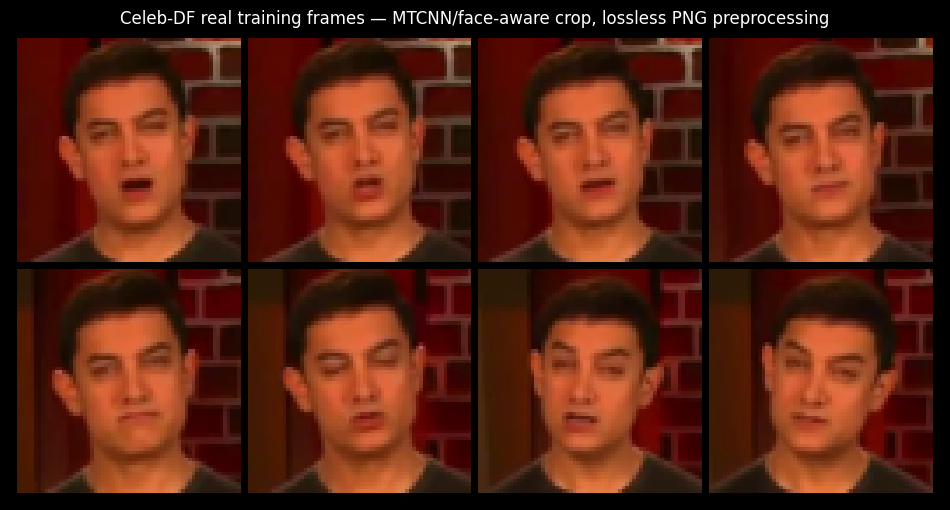

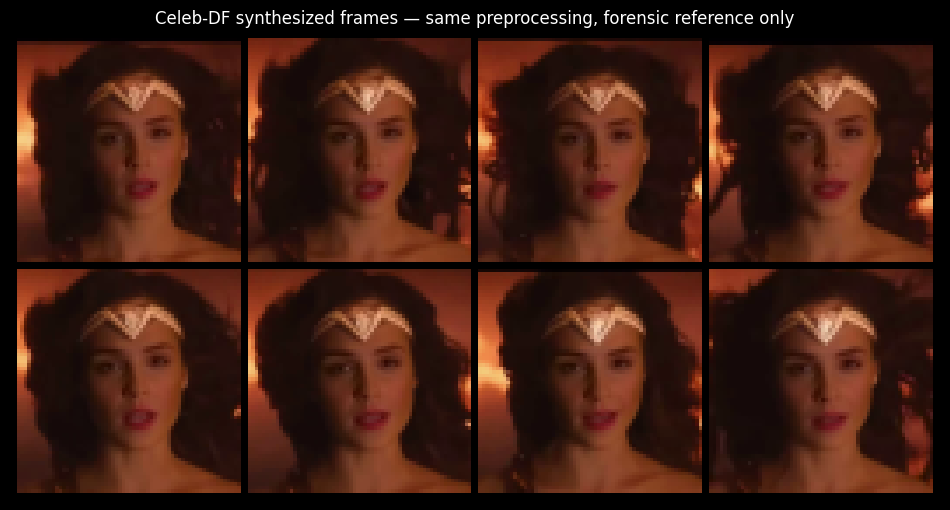

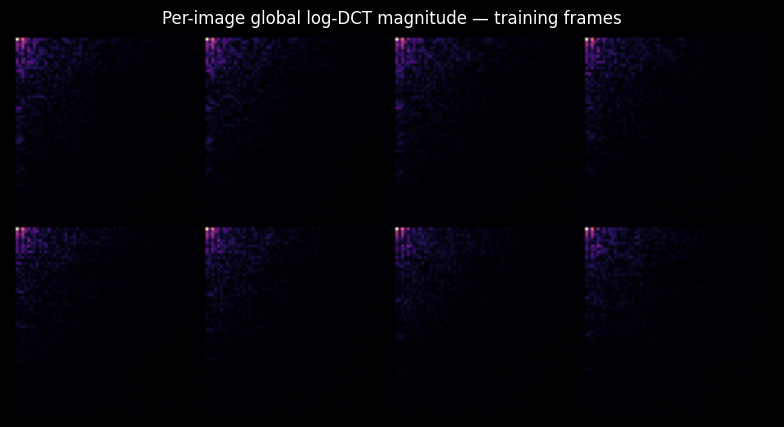

Final eval source-video groups: 30
Fake eval source-video groups:  62


In [5]:
# image dataset
class FlatImageDataset(Dataset):
    EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

    def __init__(self, root: str, transform=None):
        self.root = Path(root)
        self.transform = transform
        self.files = sorted(
            p for p in self.root.rglob("*")
            if p.is_file() and p.suffix.lower() in self.EXTENSIONS
        )
        if not self.files:
            raise FileNotFoundError(f"No images found under {self.root.resolve()}")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        with Image.open(self.files[idx]) as im:
            image = im.convert("RGB")
        return self.transform(image) if self.transform else image


def make_transform(image_size: int, train: bool = True, already_resized: bool = False):
    ops = []
    if not already_resized:
        ops += [transforms.Resize(image_size), transforms.CenterCrop(image_size)]
    if train:
        ops.append(transforms.RandomHorizontalFlip())
    ops += [transforms.ToTensor(), transforms.Normalize([0.5] * 3, [0.5] * 3)]
    return transforms.Compose(ops)


def _subset(ds: Dataset, max_samples: Optional[int], seed: int) -> Dataset:
    if max_samples is None or max_samples <= 0 or len(ds) <= max_samples:
        return ds
    g = torch.Generator().manual_seed(seed)
    ids = torch.randperm(len(ds), generator=g)[:max_samples].tolist()
    return Subset(ds, ids)


# celeb-df video splits
VIDEO_EXTENSIONS = {".mp4", ".avi", ".mov", ".mkv"}

def _is_real_celebdf_path(path: Path) -> bool:
    return path.parts[0] in {"Celeb-real", "YouTube-real"}

def _is_fake_celebdf_path(path: Path) -> bool:
    return path.parts[0] == "Celeb-synthesis"


def parse_celebdf_test_list(root: Path) -> List[Path]:
    list_file = root / "List_of_testing_videos.txt"
    if not list_file.exists():
        return []
    paths = []
    for line in list_file.read_text(encoding="utf-8").splitlines():
        line = line.strip()
        if line:
            paths.append(Path(line.split()[-1].replace("\\", "/")))
    return paths


def discover_celebdf_videos(root: Path) -> Dict[str, List[Path]]:
    required = ["Celeb-real", "YouTube-real", "Celeb-synthesis"]
    missing = [name for name in required if not (root / name).exists()]
    if missing:
        raise FileNotFoundError("Celeb-DF root is incomplete. Missing: " + ", ".join(missing))
    real = []
    for folder in ["Celeb-real", "YouTube-real"]:
        real.extend(sorted(p for p in (root / folder).rglob("*") if p.is_file() and p.suffix.lower() in VIDEO_EXTENSIONS))
    fake = sorted(p for p in (root / "Celeb-synthesis").rglob("*") if p.is_file() and p.suffix.lower() in VIDEO_EXTENSIONS)
    return {"real": real, "fake": fake}


def split_celebdf_videos(root: Path, seed: int = 42, official_val_fraction: float = 0.20):

    videos = discover_celebdf_videos(root)
    official = parse_celebdf_test_list(root)
    if official:
        official_set = {p.as_posix() for p in official}
        rel = lambda p: p.relative_to(root).as_posix()
        train_real = [p for p in videos["real"] if rel(p) not in official_set]
        official_real = [root / p for p in official if _is_real_celebdf_path(p) and (root / p).exists()]
        eval_fake = [root / p for p in official if _is_fake_celebdf_path(p) and (root / p).exists()]
        if not official_real:
            official_real = [p for p in videos["real"] if rel(p) in official_set]
        if not eval_fake:
            eval_fake = [p for p in videos["fake"] if rel(p) in official_set]

        rng = np.random.default_rng(seed + 17)
        order = rng.permutation(len(official_real)).tolist()
        n_val = max(1, int(round(official_val_fraction * len(order))))
        n_val = min(n_val, max(1, len(order) - 1))
        val_ids = set(order[:n_val])
        val_real = [p for i, p in enumerate(official_real) if i in val_ids]
        eval_real = [p for i, p in enumerate(official_real) if i not in val_ids]
    else:
        print("WARNING: official test list not found; using deterministic train/val/test video-level split.")
        rng = np.random.default_rng(seed)
        perm = rng.permutation(len(videos["real"])).tolist()
        n_test = max(1, int(0.20 * len(perm)))
        n_val = max(1, int(0.10 * len(perm)))
        test_ids, val_ids = set(perm[:n_test]), set(perm[n_test:n_test+n_val])
        eval_real = [p for i, p in enumerate(videos["real"]) if i in test_ids]
        val_real = [p for i, p in enumerate(videos["real"]) if i in val_ids]
        train_real = [p for i, p in enumerate(videos["real"]) if i not in test_ids and i not in val_ids]
        eval_fake = videos["fake"]
    return train_real, val_real, eval_real, eval_fake


def _safe_video_key(video_path: Path, root: Path) -> str:
    rel = video_path.relative_to(root).with_suffix("")
    return "__".join(rel.parts)


# face detector state
_MTCNN_DETECTOR = None
_MTCNN_CHECKED = False
_MTCNN_WARNING_SHOWN = False
_FACE_CASCADE = None
_FACE_CASCADE_CHECKED = False
_FACE_CASCADE_WARNING_SHOWN = False


# face detectors
def _get_mtcnn(cfg: Config):
    global _MTCNN_DETECTOR, _MTCNN_CHECKED, _MTCNN_WARNING_SHOWN
    if cfg.face_detector not in {"auto", "mtcnn"}:
        return None
    if _MTCNN_CHECKED:
        return _MTCNN_DETECTOR
    _MTCNN_CHECKED = True
    if not FACENET_AVAILABLE or MTCNN is None:
        if cfg.face_detector == "mtcnn" and not _MTCNN_WARNING_SHOWN:
            print("WARNING: face_detector='mtcnn' but facenet-pytorch is unavailable; falling back.")
            _MTCNN_WARNING_SHOWN = True
        return None
    try:
        dev = cfg.face_detector_device
        if str(dev).startswith("cuda") and not torch.cuda.is_available():
            dev = "cpu"
        _MTCNN_DETECTOR = MTCNN(
            keep_all=True, device=dev, min_face_size=20,
            thresholds=[0.6, 0.7, 0.7], factor=0.709, post_process=False
        )
        print(f"Face detector: MTCNN on {dev}")
    except Exception as exc:
        _MTCNN_DETECTOR = None
        if not _MTCNN_WARNING_SHOWN:
            print(f"WARNING: MTCNN could not be initialized ({exc!r}); falling back.")
            _MTCNN_WARNING_SHOWN = True
    return _MTCNN_DETECTOR


def _mtcnn_face_box(frame_rgb: np.ndarray, cfg: Config):
    detector = _get_mtcnn(cfg)
    if detector is None:
        return None
    try:
        boxes, probs = detector.detect(Image.fromarray(frame_rgb))
        if boxes is None or probs is None:
            return None
        candidates = []
        for box, prob in zip(boxes, probs):
            if prob is None or float(prob) < cfg.face_confidence:
                continue
            x0, y0, x1, y1 = [float(v) for v in box]
            bw, bh = max(1.0, x1 - x0), max(1.0, y1 - y0)
            candidates.append((float(prob) * bw * bh, (x0, y0, bw, bh)))
        return max(candidates, key=lambda z: z[0])[1] if candidates else None
    except Exception:
        return None


def _get_face_cascade():

    global _FACE_CASCADE, _FACE_CASCADE_CHECKED, _FACE_CASCADE_WARNING_SHOWN
    if _FACE_CASCADE_CHECKED:
        return _FACE_CASCADE
    _FACE_CASCADE_CHECKED = True
    if not CV2_AVAILABLE or cv2 is None:
        return None
    has_haar_api = (
        hasattr(cv2, "CascadeClassifier")
        and hasattr(cv2, "data")
        and hasattr(cv2.data, "haarcascades")
    )
    if not has_haar_api:
        if not _FACE_CASCADE_WARNING_SHOWN:
            print("WARNING: this cv2 installation has no Haar CascadeClassifier; using tighter deterministic crops when MTCNN is unavailable.")
            _FACE_CASCADE_WARNING_SHOWN = True
        return None
    try:
        cascade_path = Path(cv2.data.haarcascades) / "haarcascade_frontalface_default.xml"
        if not cascade_path.exists():
            raise FileNotFoundError(str(cascade_path))
        detector = cv2.CascadeClassifier(str(cascade_path))
        if detector is None or detector.empty():
            raise RuntimeError("OpenCV returned an empty Haar cascade")
        _FACE_CASCADE = detector
    except Exception as exc:
        _FACE_CASCADE = None
        if not _FACE_CASCADE_WARNING_SHOWN:
            print(f"WARNING: Haar face detector could not be initialized ({exc!r}); using tighter deterministic crops.")
            _FACE_CASCADE_WARNING_SHOWN = True
    return _FACE_CASCADE

# crop helpers
def _square_crop_from_box(img_rgb: np.ndarray, box, margin: float) -> np.ndarray:
    h, w = img_rgb.shape[:2]
    x, y, bw, bh = [float(v) for v in box]
    cx, cy = x + bw / 2, y + bh / 2
    side = max(bw, bh) * margin
    x0, y0 = int(round(cx - side / 2)), int(round(cy - side / 2))
    x1, y1 = int(round(cx + side / 2)), int(round(cy + side / 2))

    if x0 < 0: x1 -= x0; x0 = 0
    if y0 < 0: y1 -= y0; y0 = 0
    if x1 > w: x0 -= (x1 - w); x1 = w
    if y1 > h: y0 -= (y1 - h); y1 = h
    x0, y0 = max(0, x0), max(0, y0)
    crop = img_rgb[y0:y1, x0:x1]
    if crop.size == 0:
        return img_rgb
    return crop


def _tight_center_crop(img_rgb: np.ndarray, fraction: float = 0.78, vertical_offset: float = -0.05) -> np.ndarray:

    h, w = img_rgb.shape[:2]
    side = max(32, int(round(min(h, w) * float(fraction))))
    cx = w / 2.0
    cy = h / 2.0 + float(vertical_offset) * h
    x0 = int(round(cx - side / 2)); y0 = int(round(cy - side / 2))
    x0 = min(max(0, x0), max(0, w - side))
    y0 = min(max(0, y0), max(0, h - side))
    return img_rgb[y0:y0 + side, x0:x0 + side]


# frame preprocessing
def _preprocess_frame(frame_bgr: np.ndarray, cfg: Config) -> Tuple[Image.Image, bool]:
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    detected = False
    crop = None

    if cfg.face_crop and cfg.face_detector != "none":

        box = _mtcnn_face_box(frame_rgb, cfg)
        if box is not None:
            crop = _square_crop_from_box(frame_rgb, box, cfg.face_margin)
            detected = True


        if crop is None and cfg.face_detector in {"auto", "haar"}:
            cascade = _get_face_cascade()
            if cascade is not None:
                gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)
                min_side = max(24, int(min(gray.shape[:2]) * cfg.face_min_fraction))
                faces = cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(min_side, min_side))
                if len(faces):
                    box = max(faces, key=lambda b: int(b[2]) * int(b[3]))
                    crop = _square_crop_from_box(frame_rgb, box, cfg.face_margin)
                    detected = True


    if crop is None:
        crop = _tight_center_crop(frame_rgb, cfg.fallback_crop_fraction, cfg.fallback_vertical_offset)

    resized = cv2.resize(crop, (cfg.image_size, cfg.image_size), interpolation=cv2.INTER_AREA)
    return Image.fromarray(resized), detected

# frame extraction
def _read_frame_near(cap, frame_idx: int, frame_count: int, radius: int = 6):
    offsets = [0]
    for r in range(1, radius + 1):
        offsets += [-r, r]
    for off in offsets:
        idx = int(np.clip(frame_idx + off, 0, frame_count - 1))
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ok, frame = cap.read()
        if ok and frame is not None:
            return idx, frame
    return None, None


def resolve_face_backend(cfg: Config) -> str:
    if not cfg.face_crop or cfg.face_detector == "none":
        return "center"
    if cfg.face_detector in {"auto", "mtcnn"} and _get_mtcnn(cfg) is not None:
        return "mtcnn"
    if cfg.face_detector in {"auto", "haar"} and _get_face_cascade() is not None:
        return "haar"
    return "center"


# cache metadata
def _expected_cache_meta(cfg: Config) -> dict:
    return {
        "image_size": int(cfg.image_size),
        "format": "png",
        "cache_version": cfg.cache_version,
        "face_crop": bool(cfg.face_crop),
        "resolved_backend": resolve_face_backend(cfg),
        "face_margin": float(cfg.face_margin),
        "face_confidence": float(cfg.face_confidence),
        "fallback_crop_fraction": float(cfg.fallback_crop_fraction),
        "fallback_vertical_offset": float(cfg.fallback_vertical_offset),
    }


def _meta_matches(meta: dict, expected: dict) -> bool:
    for k, v in expected.items():
        if k not in meta:
            return False
        if isinstance(v, float):
            if abs(float(meta[k]) - v) > 1e-8:
                return False
        elif meta[k] != v:
            return False
    return True


# per-video frame cache
def extract_uniform_frames(video_path: Path, root: Path, split_cache: Path,
                           frames_per_video: int, cfg: Config, rebuild: bool = False) -> Tuple[List[Path], int]:
    if not CV2_AVAILABLE:
        raise ImportError("Celeb-DF preprocessing requires OpenCV. Install with: pip install opencv-python")

    video_dir = split_cache / _safe_video_key(video_path, root)
    video_dir.mkdir(parents=True, exist_ok=True)
    ext = ".png"
    existing = sorted(video_dir.glob(f"*{ext}"))
    all_cached_images = sorted(
        p for p in video_dir.iterdir()
        if p.is_file() and p.suffix.lower() in FlatImageDataset.EXTENSIONS
    )
    meta_path = video_dir / "meta.json"


    expected_meta = _expected_cache_meta(cfg)
    if not rebuild and len(existing) == frames_per_video and len(all_cached_images) == frames_per_video:
        if meta_path.exists():
            try:
                meta = json.loads(meta_path.read_text(encoding="utf-8"))
                if _meta_matches(meta, expected_meta):
                    return existing, int(meta.get("faces_detected", 0))
            except Exception:
                pass


    for p in video_dir.iterdir():
        if p.is_file() and (p.suffix.lower() in FlatImageDataset.EXTENSIONS or p.name == "meta.json"):
            p.unlink()

    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f"Could not open video: {video_path}")
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if frame_count <= 0:
        cap.release()
        raise RuntimeError(f"Invalid frame count: {video_path}")

    n = min(frames_per_video, frame_count)
    indices = np.linspace(0, frame_count - 1, n, dtype=int)
    saved, faces_detected = [], 0
    for j, target_idx in enumerate(indices):
        actual_idx, frame = _read_frame_near(cap, int(target_idx), frame_count)
        if frame is None:
            continue
        img, detected = _preprocess_frame(frame, cfg)
        faces_detected += int(detected)
        out = video_dir / f"frame_{j:04d}_src_{int(actual_idx):06d}.png"
        img.save(out, format="PNG", compress_level=1)
        saved.append(out)
    cap.release()

    if cfg.strict_cache_integrity and len(saved) != n:
        raise RuntimeError(f"Strict cache failure for {video_path}: expected {n}, saved {len(saved)} frames")

    meta_path.write_text(json.dumps({
        "video": str(video_path), "frames": len(saved), "faces_detected": faces_detected,
        **_expected_cache_meta(cfg),
        "face_detector_requested": cfg.face_detector,
    }, indent=2), encoding="utf-8")
    return saved, faces_detected


# split cache builder
def build_celebdf_frame_cache(root: Path, cache_root: Path, video_paths: List[Path], split_name: str,
                              frames_per_video: int, cfg: Config, rebuild: bool = False) -> Path:
    resolved_backend = resolve_face_backend(cfg)
    preproc_tag = (
        f"{cfg.cache_version}_face{int(cfg.face_crop)}_{resolved_backend}_"
        f"m{int(round(cfg.face_margin * 100))}_fb{int(round(cfg.fallback_crop_fraction * 100))}"
    )
    if cfg.debug:
        preproc_tag += "_debug"
    split_cache = cache_root / f"{cfg.image_size}px_{preproc_tag}" / split_name
    split_cache.mkdir(parents=True, exist_ok=True)

    expected_keys = {_safe_video_key(v, root) for v in video_paths}
    for child in split_cache.iterdir():
        if child.is_dir() and child.name not in expected_keys:
            shutil.rmtree(child)

    total = len(video_paths)
    print(f"[Celeb-DF] Building/validating '{split_name}' lossless PNG cache from {total} videos...")
    n_saved, n_faces = 0, 0
    for i, video_path in enumerate(video_paths, start=1):
        saved, detected = extract_uniform_frames(video_path, root, split_cache, frames_per_video, cfg, rebuild)
        n_saved += len(saved)
        n_faces += detected
        if i == 1 or i % 50 == 0 or i == total:
            print(f"  {i:4d}/{total:4d} videos | {n_saved:6d} frames | face crops detected: {n_faces:6d}")

    actual = list(split_cache.rglob("*.png"))
    all_images = [p for p in split_cache.rglob("*") if p.is_file() and p.suffix.lower() in FlatImageDataset.EXTENSIONS]
    if cfg.strict_cache_integrity and (len(actual) != n_saved or len(all_images) != n_saved):
        raise RuntimeError(
            f"Cache integrity mismatch in {split_name}: builder={n_saved}, PNG={len(actual)}, all images={len(all_images)}"
        )
    print(f"  exact cache count: {len(actual):,} PNG frames (no extra image files)")
    if n_saved:
        rate = n_faces / n_saved
        print(f"  face-detection crop rate: {100*rate:.1f}% (remainder uses deterministic centre crop)")
        if resolved_backend in {"mtcnn", "haar"} and split_name in {"train_real", "val_real"} and rate < 0.25:
            raise RuntimeError(
                f"{resolved_backend} was selected but only {100*rate:.1f}% of {split_name} frames were detected. "
                "Do not train on this cache: check the detector installation/configuration or set face_detector='none' explicitly."
            )
    return split_cache


# dataset assembly
def build_celebdf_datasets(cfg: Config):
    root, cache_root = Path(cfg.celebdf_root), Path(cfg.celebdf_frame_cache)
    train_videos, val_real_videos, eval_real_videos, eval_fake_videos = split_celebdf_videos(
        root, cfg.seed, cfg.official_real_val_fraction
    )
    if cfg.debug:
        k = cfg.celebdf_debug_videos_per_split
        train_videos = train_videos[:k]
        val_real_videos = val_real_videos[:max(1, min(k, len(val_real_videos)))]
        eval_real_videos = eval_real_videos[:k]
        eval_fake_videos = eval_fake_videos[:k]

    print(
        f"Celeb-DF videos | train real: {len(train_videos):,} | val real: {len(val_real_videos):,} | "
        f"final eval real: {len(eval_real_videos):,} | eval fake: {len(eval_fake_videos):,}"
    )

    train_dir = build_celebdf_frame_cache(root, cache_root, train_videos, "train_real",
                                          cfg.celebdf_train_frames_per_video, cfg, cfg.rebuild_celebdf_cache)
    val_real_dir = build_celebdf_frame_cache(root, cache_root, val_real_videos, "val_real",
                                             cfg.celebdf_val_frames_per_video, cfg, cfg.rebuild_celebdf_cache)
    eval_real_dir = build_celebdf_frame_cache(root, cache_root, eval_real_videos, "eval_real",
                                              cfg.celebdf_eval_frames_per_video, cfg, cfg.rebuild_celebdf_cache)
    eval_fake_dir = build_celebdf_frame_cache(root, cache_root, eval_fake_videos, "eval_fake",
                                              cfg.celebdf_fake_frames_per_video, cfg, cfg.rebuild_celebdf_cache)

    train_base = FlatImageDataset(str(train_dir), transform=make_transform(cfg.image_size, train=True, already_resized=True))

    stats_base = FlatImageDataset(str(train_dir), transform=make_transform(cfg.image_size, train=False, already_resized=True))
    val_real = FlatImageDataset(str(val_real_dir), transform=make_transform(cfg.image_size, train=False, already_resized=True))
    eval_real = FlatImageDataset(str(eval_real_dir), transform=make_transform(cfg.image_size, train=False, already_resized=True))
    eval_fake = FlatImageDataset(str(eval_fake_dir), transform=make_transform(cfg.image_size, train=False, already_resized=True))
    return train_base, stats_base, val_real, eval_real, eval_fake


def build_datasets(cfg: Config):
    train_ds, stats_ds, val_ds, eval_ds, fake_eval_ds = build_celebdf_datasets(cfg)
    train_ds = _subset(train_ds, cfg.max_train_samples, cfg.seed)
    stats_ds = _subset(stats_ds, cfg.max_train_samples, cfg.seed)
    val_ds = _subset(val_ds, min(cfg.max_eval_samples, 1024), cfg.seed + 1)
    eval_ds = _subset(eval_ds, cfg.max_eval_samples, cfg.seed + 2)
    fake_eval_ds = _subset(fake_eval_ds, cfg.max_fake_eval_samples, cfg.seed + 3)
    return train_ds, stats_ds, val_ds, eval_ds, fake_eval_ds


# data loaders
train_ds, stats_ds, val_ds, eval_ds, fake_eval_ds = build_datasets(CFG)

train_loader = DataLoader(train_ds, batch_size=CFG.batch_size, shuffle=True, drop_last=True,
                          num_workers=CFG.num_workers, pin_memory=torch.cuda.is_available(),
                          persistent_workers=CFG.num_workers > 0)
stats_loader = DataLoader(stats_ds, batch_size=CFG.eval_batch_size, shuffle=False, drop_last=False,
                          num_workers=CFG.num_workers, pin_memory=torch.cuda.is_available(),
                          persistent_workers=CFG.num_workers > 0)
val_loader = DataLoader(val_ds, batch_size=CFG.eval_batch_size, shuffle=False, drop_last=False,
                        num_workers=CFG.num_workers, pin_memory=torch.cuda.is_available(),
                        persistent_workers=CFG.num_workers > 0)
eval_loader = DataLoader(eval_ds, batch_size=CFG.eval_batch_size, shuffle=False, drop_last=False,
                         num_workers=CFG.num_workers, pin_memory=torch.cuda.is_available(),
                         persistent_workers=CFG.num_workers > 0)
fake_eval_loader = None if fake_eval_ds is None else DataLoader(
    fake_eval_ds, batch_size=CFG.eval_batch_size, shuffle=False, drop_last=False,
    num_workers=CFG.num_workers, pin_memory=torch.cuda.is_available(), persistent_workers=CFG.num_workers > 0)

print(f"Train REAL frames: {len(train_ds):,}")
print(f"Validation REAL frames: {len(val_ds):,}")
print(f"Final eval REAL frames: {len(eval_ds):,}")
if fake_eval_ds is not None:
    print(f"Eval FAKE frames:  {len(fake_eval_ds):,} (forensic reference only)")

# fit frequency statistics
frequency_codec = build_frequency_codec(CFG).to(CFG.device)
frequency_codec.fit_stats(stats_loader, min(CFG.spectral_stats_samples, len(stats_ds)), CFG.device)


with torch.no_grad():
    _pz = frequency_codec.partial_latent_std()
    print("\nSNR-balance diagnostic (same fitted partial latent; lower ratio = more uniform effective SNR)")
    for _q in (0.0, 0.50, CFG.diffusion_balance_power, 1.0):
        _state_std = _pz / _pz.clamp_min(1e-6).pow(float(_q))
        _ratio = float((_state_std.max() / _state_std.min().clamp_min(1e-12)).item())
        print(f"  q={float(_q):.2f}: state std=[{_state_std.min().item():.4g}, {_state_std.max().item():.4g}] ratio={_ratio:.2f}x")
analysis_dct = GlobalDCTTransform(CFG.image_size).to(CFG.device)

# transform checks
example = next(iter(stats_loader))[:8].to(CFG.device)
err_model = test_codec_roundtrip(frequency_codec, example, "SNR-balanced global-DCT/IDCT")
err_global = test_codec_roundtrip(analysis_dct, example, "global DCT/IDCT")


assert err_model < 5e-4 and err_global < 5e-4, (
    f"DCT round-trip check failed: model={err_model:.3e}, global={err_global:.3e}. "
    "Re-run the CUDA/GPU check cell so TF32 is disabled for torch.matmul."
)
with torch.no_grad():
    z_rt = frequency_codec.encode(example.float())
    x_rt = frequency_codec.decode(z_rt, clamp=False)
    codec_max = float((example.float() - x_rt).abs().max().item())
    codec_rmse = float((example.float() - x_rt).pow(2).mean().sqrt().item())
print(f"encode/decode round-trip | max={codec_max:.3e} | RMSE={codec_rmse:.3e}")
assert codec_max < 5e-4, f"Whitening encode/decode round trip failed: {codec_max:.3e}"

crop_mode = ("MTCNN/face-aware crop" if _get_mtcnn(CFG) is not None else
             ("Haar face-aware crop" if _get_face_cascade() is not None else "tight deterministic centre crop"))
show_images(example, nrow=4, title=f"Celeb-DF real training frames — {crop_mode}, lossless PNG preprocessing")
if fake_eval_loader is not None:
    show_images(next(iter(fake_eval_loader))[:8], nrow=4, title="Celeb-DF synthesized frames — same preprocessing, forensic reference only")

with torch.no_grad():
    spec = analysis_dct.raw_dct(example)
    vis = torch.log1p(spec.abs()).mean(dim=1, keepdim=True)
    vis = (vis - vis.amin(dim=(-2, -1), keepdim=True)) / (vis.amax(dim=(-2, -1), keepdim=True) - vis.amin(dim=(-2, -1), keepdim=True) + 1e-8)
    grid = make_grid(vis.cpu(), nrow=4)
    plt.figure(figsize=(10, 5))
    plt.imshow(grid[0].numpy(), cmap="magma")
    plt.title("Per-image global log-DCT magnitude — training frames")
    plt.axis("off")
    plt.show()


# source-video groups
def dataset_group_ids(ds: Dataset) -> np.ndarray:

    if isinstance(ds, Subset):
        base = dataset_group_ids(ds.dataset)
        return np.asarray(base, dtype=object)[np.asarray(ds.indices, dtype=int)]
    if isinstance(ds, FlatImageDataset):
        return np.asarray([
            p.parent.relative_to(ds.root).as_posix() for p in ds.files
        ], dtype=object)
    return np.asarray([f"sample_{i:08d}" for i in range(len(ds))], dtype=object)


eval_group_ids = dataset_group_ids(eval_ds)
fake_eval_group_ids = None if fake_eval_ds is None else dataset_group_ids(fake_eval_ds)
print(f"Final eval source-video groups: {len(np.unique(eval_group_ids)):,}")
if fake_eval_group_ids is not None:
    print(f"Fake eval source-video groups:  {len(np.unique(fake_eval_group_ids)):,}")


# Network

Both models use the same compact DDPM U-Net family and approximately the same number of parameters, so the comparison is mainly about the representation rather than model capacity. The RGB baseline receives three image channels, while the frequency model receives the three normalized DCT channels.

For the frequency model I add three coordinate maps that indicate horizontal frequency, vertical frequency and radial frequency. I also use depth-wise large-kernel mixing in the first encoder levels. These changes give the network explicit information about the position of a coefficient in the spectrum and a slightly wider local context, which is useful because neighbouring DCT coefficients have a different meaning from neighbouring RGB pixels.

The diffusion process uses a cosine noise schedule, 1000 forward steps, v-prediction, Min-SNR weighting and self-conditioning.

In [6]:
# normalization helper
def _gn_groups(ch: int) -> int:
    for g in (32, 16, 8, 4, 2, 1):
        if ch % g == 0:
            return g
    return 1


# time embedding
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim: int):
        super().__init__(); self.dim = dim
    def forward(self, t: torch.Tensor) -> torch.Tensor:
        half = self.dim // 2
        scale = math.log(10000) / max(half - 1, 1)
        emb = torch.exp(torch.arange(half, device=t.device) * -scale)
        emb = t.float()[:, None] * emb[None, :]
        emb = torch.cat([emb.sin(), emb.cos()], dim=1)
        return F.pad(emb, (0, 1)) if self.dim % 2 else emb


# unet blocks
class ResBlock(nn.Module):

    def __init__(self, in_ch: int, out_ch: int, time_dim: int, dropout: float = 0.0):
        super().__init__()
        self.norm1 = nn.GroupNorm(_gn_groups(in_ch), in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.time = nn.Sequential(nn.SiLU(), nn.Linear(time_dim, out_ch * 2))
        self.norm2 = nn.GroupNorm(_gn_groups(out_ch), out_ch)
        self.dropout = nn.Dropout(dropout)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        h = self.conv1(F.silu(self.norm1(x)))
        scale, shift = self.time(t_emb).chunk(2, dim=1)
        h = self.norm2(h)
        h = h * (1 + scale[:, :, None, None]) + shift[:, :, None, None]
        h = self.conv2(self.dropout(F.silu(h)))
        return (h + self.skip(x)) / math.sqrt(2.0)


class Attention2d(nn.Module):
    def __init__(self, ch: int, heads: int = 4):
        super().__init__()
        heads = min(heads, ch)
        while ch % heads != 0:
            heads -= 1
        self.heads, self.head_dim = heads, ch // heads
        self.norm = nn.GroupNorm(_gn_groups(ch), ch)
        self.qkv = nn.Conv2d(ch, ch * 3, 1)
        self.proj = nn.Conv2d(ch, ch, 1)

    def forward(self, x):
        residual = x
        b, c, h, w = x.shape
        n = h * w
        qkv = self.qkv(self.norm(x)).reshape(b, 3, self.heads, self.head_dim, n)
        q, k, v = qkv.unbind(dim=1)
        q = q.transpose(-2, -1).contiguous()
        k = k.transpose(-2, -1).contiguous()
        v = v.transpose(-2, -1).contiguous()
        scale = self.head_dim ** -0.5
        scores = torch.matmul(q.float(), k.float().transpose(-2, -1)) * scale
        weights = torch.softmax(scores, dim=-1)
        out = torch.matmul(weights, v.float()).to(dtype=qkv.dtype)
        out = out.transpose(-2, -1).contiguous().reshape(b, c, h, w)
        return (residual + self.proj(out)) / math.sqrt(2.0)


class LargeKernelMix(nn.Module):
    def __init__(self, ch: int, kernel: int = 5):
        super().__init__()
        self.norm = nn.GroupNorm(_gn_groups(ch), ch)
        self.dw = nn.Conv2d(ch, ch, kernel, padding=kernel // 2, groups=ch)
        self.pw = nn.Conv2d(ch, ch, 1)
    def forward(self, x):
        return (x + self.pw(self.dw(F.silu(self.norm(x))))) / math.sqrt(2.0)


class DownsampleConv(nn.Module):
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, 3, stride=2, padding=1)
    def forward(self, x):
        return self.conv(x)


class UpsampleConv(nn.Module):
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, 3, padding=1)
    def forward(self, x):
        return self.conv(F.interpolate(x, scale_factor=2.0, mode="nearest"))


# ddpm unet
class SmallDDPMUNet(nn.Module):
    def __init__(self, data_channels: int = 3, base: int = 64, dropout: float = 0.1,
                 coord_mode: str = "none", large_kernel_mix: bool = False,
                 large_kernel_size: int = 5, attention_level2: bool = False,
                 self_condition: bool = False):
        super().__init__()
        self.data_channels = data_channels
        self.coord_mode = coord_mode
        self.self_condition = self_condition
        extra = 3 if coord_mode != "none" else 0
        in_data = data_channels * (2 if self_condition else 1)
        time_dim = base * 4
        self.time_mlp = nn.Sequential(
            SinusoidalTimeEmbedding(base), nn.Linear(base, time_dim), nn.SiLU(), nn.Linear(time_dim, time_dim)
        )
        self.in_conv = nn.Conv2d(in_data + extra, base, 3, padding=1)

        # encoder
        self.e1a = ResBlock(base, base, time_dim, dropout)
        self.mix1 = LargeKernelMix(base, large_kernel_size) if large_kernel_mix else nn.Identity()
        self.e1b = ResBlock(base, base, time_dim, dropout)
        self.down1 = DownsampleConv(base, base * 2)

        self.e2a = ResBlock(base * 2, base * 2, time_dim, dropout)
        self.mix2 = LargeKernelMix(base * 2, large_kernel_size) if large_kernel_mix else nn.Identity()
        self.e2attn = Attention2d(base * 2) if attention_level2 else nn.Identity()
        self.e2b = ResBlock(base * 2, base * 2, time_dim, dropout)
        self.down2 = DownsampleConv(base * 2, base * 4)

        self.e3a = ResBlock(base * 4, base * 4, time_dim, dropout)
        self.e3attn = Attention2d(base * 4)
        self.e3b = ResBlock(base * 4, base * 4, time_dim, dropout)
        self.down3 = DownsampleConv(base * 4, base * 4)

        # bottleneck
        self.mid1 = ResBlock(base * 4, base * 4, time_dim, dropout)
        self.midattn = Attention2d(base * 4)
        self.mid2 = ResBlock(base * 4, base * 4, time_dim, dropout)

        # decoder
        self.up3 = UpsampleConv(base * 4, base * 4)
        self.u3a = ResBlock(base * 8, base * 4, time_dim, dropout)
        self.u3b = ResBlock(base * 4, base * 4, time_dim, dropout)
        self.up2 = UpsampleConv(base * 4, base * 2)
        self.u2a = ResBlock(base * 4, base * 2, time_dim, dropout)
        self.u2b = ResBlock(base * 2, base * 2, time_dim, dropout)
        self.up1 = UpsampleConv(base * 2, base)
        self.u1a = ResBlock(base * 2, base, time_dim, dropout)
        self.u1b = ResBlock(base, base, time_dim, dropout)

        self.out_norm = nn.GroupNorm(_gn_groups(base), base)
        self.out_conv = nn.Conv2d(base, data_channels, 3, padding=1)
        nn.init.zeros_(self.out_conv.weight)
        nn.init.zeros_(self.out_conv.bias)

    def _coords(self, x: torch.Tensor) -> torch.Tensor:
        b, _, h, w = x.shape
        if self.coord_mode == "dct":

            vv, uu = torch.meshgrid(
                torch.linspace(0, 1, h, device=x.device, dtype=x.dtype),
                torch.linspace(0, 1, w, device=x.device, dtype=x.dtype), indexing="ij"
            )
            rr = torch.sqrt(uu ** 2 + vv ** 2) / math.sqrt(2.0)
            c = torch.stack([uu, vv, rr], dim=0).unsqueeze(0)
        else:
            yy, xx = torch.meshgrid(
                torch.linspace(-1, 1, h, device=x.device, dtype=x.dtype),
                torch.linspace(-1, 1, w, device=x.device, dtype=x.dtype), indexing="ij"
            )
            rr = torch.sqrt(xx ** 2 + yy ** 2) / math.sqrt(2.0)
            c = torch.stack([xx, yy, rr], dim=0).unsqueeze(0)
        return c.expand(b, -1, -1, -1)

    def forward(self, x: torch.Tensor, t: torch.Tensor, self_cond: Optional[torch.Tensor] = None) -> torch.Tensor:
        te = self.time_mlp(t)
        if self.self_condition:
            if self_cond is None:
                self_cond = torch.zeros_like(x)
            x = torch.cat([x, self_cond], dim=1)
        if self.coord_mode != "none":
            x = torch.cat([x, self._coords(x)], dim=1)
        x = self.in_conv(x)
        s1 = self.e1b(self.mix1(self.e1a(x, te)), te)
        x = self.down1(s1)
        x = self.e2a(x, te)
        x = self.mix2(x)
        x = self.e2attn(x)
        s2 = self.e2b(x, te)
        x = self.down2(s2)
        x = self.e3a(x, te)
        x = self.e3attn(x)
        s3 = self.e3b(x, te)
        x = self.down3(s3)
        x = self.mid2(self.midattn(self.mid1(x, te)), te)
        x = self.up3(x)
        x = self.u3b(self.u3a(torch.cat([x, s3], dim=1), te), te)
        x = self.up2(x)
        x = self.u2b(self.u2a(torch.cat([x, s2], dim=1), te), te)
        x = self.up1(x)
        x = self.u1b(self.u1a(torch.cat([x, s1], dim=1), te), te)
        return self.out_conv(F.silu(self.out_norm(x)))


# model factory
def build_model(domain: str, cfg: Config, codec: nn.Module) -> nn.Module:
    if domain == "rgb":
        return SmallDDPMUNet(
            3, cfg.rgb_base_channels, cfg.dropout,
            coord_mode="none", large_kernel_mix=False,
            attention_level2=False, self_condition=cfg.self_condition
        )
    if domain == "frequency":
        return SmallDDPMUNet(
            codec.latent_channels, cfg.frequency_base_channels, cfg.dropout,
            coord_mode="dct" if cfg.frequency_coord_conditioning else "none",
            large_kernel_mix=cfg.frequency_large_kernel_mix,
            large_kernel_size=cfg.large_kernel_size,
            attention_level2=cfg.frequency_attention_level2,
            self_condition=cfg.self_condition
        )
    raise ValueError(domain)


# diffusion schedule
def cosine_beta_schedule(timesteps: int, s: float = 0.008) -> torch.Tensor:
    steps = timesteps + 1
    x = torch.linspace(0, timesteps, steps)
    acp = torch.cos(((x / timesteps) + s) / (1 + s) * math.pi * 0.5) ** 2
    acp = acp / acp[0]
    betas = 1 - (acp[1:] / acp[:-1])
    return betas.clamp(1e-5, 0.999)


# diffusion process
class GaussianDiffusion(nn.Module):
    def __init__(self, timesteps: int = 1000, beta_schedule: str = "cosine",
                 prediction_type: str = "v", min_snr_gamma: Optional[float] = 5.0,
                 self_condition_prob: float = 0.5):
        super().__init__()
        if prediction_type not in {"epsilon", "v", "x0"}:
            raise ValueError("prediction_type must be epsilon, v, or x0")
        self.prediction_type = prediction_type
        self.min_snr_gamma = min_snr_gamma
        self.self_condition_prob = float(self_condition_prob)
        betas = cosine_beta_schedule(timesteps) if beta_schedule == "cosine" else torch.linspace(1e-4, 2e-2, timesteps)
        alphas = 1.0 - betas
        acp = torch.cumprod(alphas, dim=0)
        acp_prev = F.pad(acp[:-1], (1, 0), value=1.0)
        self.timesteps = timesteps
        for name, value in {
            "betas": betas, "alphas": alphas, "acp": acp, "acp_prev": acp_prev,
            "sqrt_acp": torch.sqrt(acp), "sqrt_one_minus_acp": torch.sqrt(1.0 - acp),
            "sqrt_recip_acp": torch.sqrt(1.0 / acp), "sqrt_recipm1_acp": torch.sqrt(1.0 / acp - 1),
            "posterior_variance": betas * (1.0 - acp_prev) / (1.0 - acp),
            "posterior_mean_coef1": betas * torch.sqrt(acp_prev) / (1.0 - acp),
            "posterior_mean_coef2": (1.0 - acp_prev) * torch.sqrt(alphas) / (1.0 - acp),
        }.items():
            self.register_buffer(name, value.float())

    def q_sample(self, x0, t, noise=None):
        noise = torch.randn_like(x0) if noise is None else noise
        return extract(self.sqrt_acp, t, x0.shape) * x0 + extract(self.sqrt_one_minus_acp, t, x0.shape) * noise

    def predict_x0_from_epsilon(self, xt, t, eps):
        return extract(self.sqrt_recip_acp, t, xt.shape) * xt - extract(self.sqrt_recipm1_acp, t, xt.shape) * eps

    def predict_x0_from_v(self, xt, t, v):
        return extract(self.sqrt_acp, t, xt.shape) * xt - extract(self.sqrt_one_minus_acp, t, xt.shape) * v

    def predict_epsilon_from_v(self, xt, t, v):
        return extract(self.sqrt_one_minus_acp, t, xt.shape) * xt + extract(self.sqrt_acp, t, xt.shape) * v

    def v_target(self, x0, t, noise):
        return extract(self.sqrt_acp, t, x0.shape) * noise - extract(self.sqrt_one_minus_acp, t, x0.shape) * x0

    def model_predictions(self, model: nn.Module, xt: torch.Tensor, t: torch.Tensor,
                          self_cond: Optional[torch.Tensor] = None):
        pred = model(xt, t, self_cond)
        if self.prediction_type == "epsilon":
            eps = pred
            x0 = self.predict_x0_from_epsilon(xt, t, eps)
        elif self.prediction_type == "v":
            x0 = self.predict_x0_from_v(xt, t, pred)
            eps = self.predict_epsilon_from_v(xt, t, pred)
        else:
            x0 = pred
            eps = (xt - extract(self.sqrt_acp, t, xt.shape) * x0) / extract(self.sqrt_one_minus_acp, t, xt.shape).clamp_min(1e-8)
        return pred, x0, eps

    def _loss_weights(self, t: torch.Tensor) -> torch.Tensor:
        if self.min_snr_gamma is None:
            return torch.ones_like(t, dtype=torch.float32)
        acp = self.acp.gather(0, t).float()
        snr = acp / (1.0 - acp).clamp_min(1e-8)
        clipped = torch.minimum(snr, torch.full_like(snr, float(self.min_snr_gamma)))
        if self.prediction_type == "epsilon":
            return clipped / snr.clamp_min(1e-8)
        if self.prediction_type == "x0":
            return clipped
        return clipped / (snr + 1.0)

    # training objective
    def training_terms(self, model: nn.Module, x0: torch.Tensor, enable_self_condition: bool = True):
        b = x0.shape[0]
        t = torch.randint(0, self.timesteps, (b,), device=x0.device, dtype=torch.long)
        noise = torch.randn_like(x0)
        xt = self.q_sample(x0, t, noise)

        self_cond = None
        if enable_self_condition and getattr(model, "self_condition", False) and random.random() < self.self_condition_prob:
            with torch.no_grad():
                _, x0_sc, _ = self.model_predictions(model, xt, t, None)
                self_cond = x0_sc.detach()

        pred, x0_pred, eps_pred = self.model_predictions(model, xt, t, self_cond)
        if self.prediction_type == "epsilon":
            target = noise
        elif self.prediction_type == "v":
            target = self.v_target(x0, t, noise)
        else:
            target = x0
        per_sample = (pred - target).pow(2).flatten(1).mean(1)
        weights = self._loss_weights(t)
        objective = (per_sample * weights).mean()
        return {
            "loss": objective, "objective": objective, "raw_mse": per_sample.mean(),
            "t": t, "xt": xt, "noise": noise, "x0_pred": x0_pred,
            "eps_pred": eps_pred, "self_cond": self_cond
        }

    def deterministic_ddim_jump(self, x0_pred: torch.Tensor, eps_pred: torch.Tensor,
                                t_next: torch.Tensor) -> torch.Tensor:

        a_next = extract(self.acp, t_next, x0_pred.shape)
        return torch.sqrt(a_next) * x0_pred + torch.sqrt((1.0 - a_next).clamp_min(0.0)) * eps_pred

    # ancestral sampling
    @torch.no_grad()
    def ddpm_sample(self, model, shape, device, clip_range=1.0):
        x = torch.randn(shape, device=device)
        self_cond = None
        for i in reversed(range(self.timesteps)):
            t = torch.full((shape[0],), i, device=device, dtype=torch.long)
            _, x0, _ = self.model_predictions(model, x, t, self_cond)
            if clip_range is not None:
                x0 = x0.clamp(-clip_range, clip_range)
            if getattr(model, "self_condition", False):
                self_cond = x0
            mean = extract(self.posterior_mean_coef1, t, x.shape) * x0 + extract(self.posterior_mean_coef2, t, x.shape) * x
            if i > 0:
                var = extract(self.posterior_variance, t, x.shape)
                x = mean + torch.sqrt(var.clamp_min(1e-20)) * torch.randn_like(x)
            else:
                x = mean
        return x

    # ddim sampling
    @torch.no_grad()
    def ddim_sample(self, model, shape, device, steps=50, eta=0.0, clip_range=1.0):
        steps = min(int(steps), self.timesteps)
        times = torch.linspace(self.timesteps - 1, 0, steps, device=device).long()
        x = torch.randn(shape, device=device)
        self_cond = None
        for idx, ti in enumerate(times):
            t = torch.full((shape[0],), int(ti.item()), device=device, dtype=torch.long)
            _, x0, eps = self.model_predictions(model, x, t, self_cond)
            if clip_range is not None:
                x0 = x0.clamp(-clip_range, clip_range)
            if getattr(model, "self_condition", False):
                self_cond = x0
            if idx == len(times) - 1:
                x = x0
                break
            t_next = times[idx + 1]
            a_t, a_next = self.acp[ti], self.acp[t_next]
            sigma = eta * torch.sqrt(((1-a_next)/(1-a_t) * (1-a_t/a_next)).clamp_min(0.0))
            c = torch.sqrt((1 - a_next - sigma**2).clamp_min(0.0))
            noise = torch.randn_like(x) if eta > 0 else 0.0
            x = torch.sqrt(a_next) * x0 + c * eps + sigma * noise
        return x


# shape checks
for _domain in ["frequency", "rgb"]:
    _m = build_model(_domain, CFG, frequency_codec).to(CFG.device)
    if _domain == "frequency":
        _shape = (2, frequency_codec.latent_channels, frequency_codec.latent_size, frequency_codec.latent_size)
    else:
        _shape = (2, 3, CFG.image_size, CFG.image_size)
    _x = torch.randn(_shape, device=CFG.device)
    _t = torch.randint(0, CFG.timesteps, (2,), device=CFG.device)
    with torch.no_grad():
        _y = _m(_x, _t, None)
    assert _y.shape == _x.shape
    print(f"{_domain:9s} UNet parameters: {sum(p.numel() for p in _m.parameters()):,} | state={_shape[1:]}")
    del _m, _x, _t, _y
if torch.cuda.is_available():
    torch.cuda.empty_cache()


frequency UNet parameters: 13,259,011 | state=(3, 64, 64)
rgb       UNet parameters: 13,231,235 | state=(3, 64, 64)


# Train

The basic objective is the standard diffusion denoising loss in the selected domain. For the frequency model, the DCT coefficients are the actual diffusion state. Because the inverse transform is differentiable, selected predictions can also be decoded to RGB during training and compared with the target image.

The auxiliary terms are introduced gradually. They include multi-scale reconstruction, image-gradient and Laplacian-detail losses, together with losses on radial spectral bands. A small trajectory term also checks a deterministic DDIM jump during training. These terms were added to improve spatial coherence and to prevent the model from matching only the dominant low-frequency coefficients.

Training uses mixed precision on CUDA, gradient clipping, EMA weights, learning-rate warm-up, checkpointing and early stopping. The RGB baseline is trained with the same diffusion formulation but without the frequency-specific auxiliary terms.

[frequency] completed checkpoint exists; skipping training -> Frequency_Domain_Diffusion_Artifacts\checkpoints\frequency_v7_trajspec_globaldct_q0.75_wp0.60_abs0.0100_traj0.0040_globaldct_wp0.60_q0.75_best.pt
Loading matched RGB baseline: Frequency_Domain_Diffusion_Artifacts\checkpoints\rgb_v4_overlap_k8s4_wp0.65_sp0.16_rad0.06_spatial_best.pt


,model,epoch,total,objective,raw_mse,spatial,edge,laplacian,boundary,latent,...,preview_hf_ratio,preview_rel_band,preview_abs_band,loss,spatial_l1,edge_l1,boundary_l1,latent_l1,fft_l1,radial_l1
0,frequency,1,0.104573,0.104154,0.420574,0.006324,0.001145,0.002857,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,frequency,2,0.105212,0.104734,0.423479,0.006723,0.001141,0.002874,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,frequency,3,0.105877,0.105342,0.422034,0.006813,0.001130,0.002855,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,frequency,4,0.105403,0.104808,0.423581,0.006882,0.001143,0.002892,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,frequency,5,0.104609,0.103970,0.423645,0.006936,0.001108,0.002821,0.0,0.0,...,0.079478,1.037405,2.077299,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,frequency,6,0.104590,0.103997,0.421060,0.006876,0.001122,0.002854,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,frequency,7,0.104538,0.103940,0.420062,0.007006,0.001135,0.002881,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,frequency,8,0.102771,0.102178,0.424553,0.006730,0.001097,0.002782,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,frequency,9,0.103599,0.103005,0.419575,0.006793,0.001112,0.002829,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,frequency,10,0.104063,0.103458,0.418344,0.006844,0.001126,0.002861,0.0,0.0,...,0.069144,1.194515,2.008116,NaN,NaN,NaN,NaN,NaN,NaN,NaN


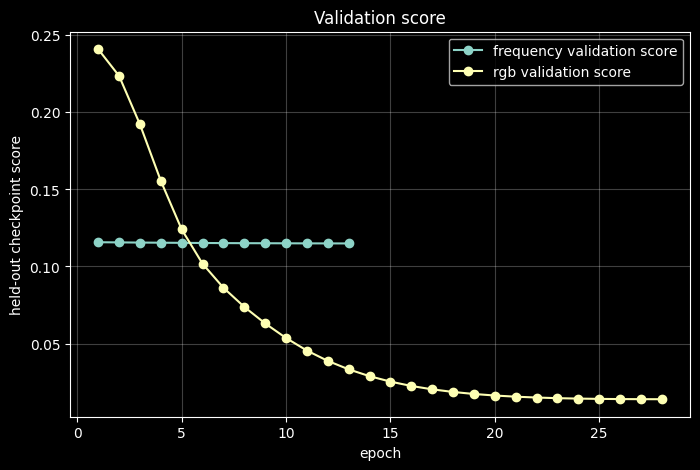

In [7]:
# exponential moving average
class EMA:
    def __init__(self, model: nn.Module, decay: float = 0.999):
        self.decay = decay
        self.model = copy.deepcopy(model).eval()
        for p in self.model.parameters(): p.requires_grad_(False)
    @torch.no_grad()
    def update(self, model: nn.Module):
        src = dict(model.named_parameters())
        for name, p_ema in self.model.named_parameters():
            p_ema.mul_(self.decay).add_(src[name].detach(), alpha=1 - self.decay)
        src_b = dict(model.named_buffers())
        for name, b_ema in self.model.named_buffers():
            if name in src_b: b_ema.copy_(src_b[name])


# domain conversion
def domain_batch(rgb: torch.Tensor, domain: str, codec: nn.Module) -> torch.Tensor:
    if domain == "rgb":
        return rgb
    if domain == "frequency":
        with torch.no_grad():
            return codec.encode(rgb.float())
    raise ValueError(domain)


# checkpoint paths
def _checkpoint_stem(domain: str, cfg: Config) -> str:
    if domain == "frequency":
        return (
            f"frequency_{cfg.experiment_name}_globaldct_wp{cfg.spectral_whitening_power:.2f}_q{cfg.diffusion_balance_power:.2f}"
        )
    if domain == "rgb":
        return f"rgb_{cfg.experiment_name}_spatial"
    raise ValueError(domain)


def checkpoint_path(domain: str, cfg: Config, kind: str = "best") -> str:
    if kind not in ("best", "last"):
        raise ValueError("kind must be 'best' or 'last'")
    return str(Path(cfg.checkpoint_dir) / f"{_checkpoint_stem(domain, cfg)}_{kind}.pt")


def completion_marker_path(domain: str, cfg: Config) -> str:
    return str(Path(cfg.checkpoint_dir) / f"{_checkpoint_stem(domain, cfg)}.complete.json")


# atomic saves
def _atomic_torch_save(payload: dict, path: str):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(path.suffix + ".tmp")
    torch.save(payload, tmp)
    os.replace(tmp, path)


def _atomic_json_save(payload: dict, path: str):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(path.suffix + ".tmp")
    with open(tmp, "w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2)
    os.replace(tmp, path)


# checkpoint payloads
def save_artifact(path: str, model: nn.Module, ema: EMA, domain: str, cfg: Config,
                  codec: nn.Module, history: list, best_val: float):
    _atomic_torch_save({
        "model_version": "frequency-dct-final",
        "model": model.state_dict(),
        "ema": ema.model.state_dict(),
        "domain": domain,
        "cfg": asdict(cfg),
        "codec_type": getattr(codec, "codec_type", "unknown"),
        "codec_state": {k: v.detach().cpu() for k, v in codec.state_dict().items()},
        "codec_stats_ready": bool(getattr(codec, "stats_ready", False)),
        "codec_whitening_power": float(getattr(codec, "whitening_power", 1.0)),
        "codec_balance_power": float(getattr(codec, "balance_power", 0.0)),
        "history": history,
        "best_val": best_val,
    }, path)


def save_training_state(path: str, model: nn.Module, ema: EMA, optimizer, scheduler,
                        scaler, domain: str, cfg: Config, codec: nn.Module,
                        history: list, best_val: float, bad_epochs: int,
                        completed_epoch: int):
    _atomic_torch_save({
        "model_version": "frequency-dct-final-resume",
        "domain": domain,
        "completed_epoch": int(completed_epoch),
        "model": model.state_dict(),
        "ema": ema.model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "scheduler": scheduler.state_dict(),
        "scaler": scaler.state_dict(),
        "cfg": asdict(cfg),
        "codec_type": getattr(codec, "codec_type", "unknown"),
        "codec_state": {k: v.detach().cpu() for k, v in codec.state_dict().items()},
        "codec_stats_ready": bool(getattr(codec, "stats_ready", False)),
        "codec_whitening_power": float(getattr(codec, "whitening_power", 1.0)),
        "codec_balance_power": float(getattr(codec, "balance_power", 0.0)),
        "history": history,
        "best_val": float(best_val),
        "bad_epochs": int(bad_epochs),
    }, path)


# checkpoint loading
def restore_codec_state(codec: nn.Module, payload: dict):
    state = payload.get("codec_state")
    if state:
        codec.load_state_dict(state, strict=True)
    elif "codec_mean" in payload and "codec_std" in payload:
        codec.mean.copy_(payload["codec_mean"].to(codec.mean.device))
        codec.std.copy_(payload["codec_std"].to(codec.std.device))
    codec.stats_ready = bool(payload.get("codec_stats_ready", True))


def _make_diffusion(cfg: Config) -> GaussianDiffusion:
    return GaussianDiffusion(
        cfg.timesteps, cfg.beta_schedule, cfg.prediction_type,
        cfg.min_snr_gamma, cfg.self_condition_prob
    )


def _validate_frequency_checkpoint(payload: dict, codec: nn.Module):
    if payload.get("codec_type") not in (None, getattr(codec, "codec_type", None)):
        raise ValueError("Frequency checkpoint codec type does not match current codec.")
    saved_wp = payload.get("codec_whitening_power")
    if saved_wp is not None and abs(
        float(saved_wp) - float(getattr(codec, "whitening_power", saved_wp))
    ) > 1e-8:
        raise ValueError(
            f"Checkpoint whitening power {saved_wp} != current "
            f"{getattr(codec, 'whitening_power', None)}"
        )
    saved_q = payload.get("codec_balance_power")
    if saved_q is not None and abs(
        float(saved_q) - float(getattr(codec, "balance_power", saved_q))
    ) > 1e-8:
        raise ValueError(
            f"Checkpoint balance power {saved_q} != current "
            f"{getattr(codec, 'balance_power', None)}"
        )


def load_artifact(path: str, domain: str, cfg: Config, codec: nn.Module) -> dict:
    payload = torch.load(path, map_location=cfg.device, weights_only=False)
    if payload.get("domain") != domain:
        raise ValueError(
            f"Checkpoint domain mismatch: expected {domain}, found {payload.get('domain')}"
        )


    if domain == "frequency":
        _validate_frequency_checkpoint(payload, codec)
        restore_codec_state(codec, payload)

    model = build_model(domain, cfg, codec).to(cfg.device)
    model.load_state_dict(payload["model"], strict=True)
    ema_model = build_model(domain, cfg, codec).to(cfg.device)
    ema_model.load_state_dict(payload["ema"], strict=True)
    ema_model.eval()
    for p in ema_model.parameters():
        p.requires_grad_(False)

    diffusion = _make_diffusion(cfg).to(cfg.device)
    return {
        "model": model, "ema": ema_model, "diffusion": diffusion,
        "history": payload.get("history", []), "checkpoint": path,
        "best_val": payload.get("best_val", float("nan"))
    }


def load_rgb_baseline_checkpoint(path: str, cfg: Config, codec: nn.Module) -> dict:

    payload = torch.load(path, map_location=cfg.device, weights_only=False)
    if payload.get("domain") != "rgb":
        raise ValueError("Requested matched baseline checkpoint is not an RGB checkpoint.")
    saved = payload.get("cfg", {})
    keys = ["image_size", "timesteps", "beta_schedule", "prediction_type",
            "self_condition", "rgb_base_channels"]
    mismatches = []
    for key in keys:
        if key in saved and saved[key] != getattr(cfg, key):
            mismatches.append((key, saved[key], getattr(cfg, key)))
    if mismatches:
        raise ValueError(f"RGB baseline checkpoint is not compatible with the current configuration: {mismatches}")

    model = build_model("rgb", cfg, codec).to(cfg.device)
    model.load_state_dict(payload["model"], strict=True)
    ema_model = build_model("rgb", cfg, codec).to(cfg.device)
    ema_model.load_state_dict(payload["ema"], strict=True)
    ema_model.eval()
    for p in ema_model.parameters():
        p.requires_grad_(False)
    return {
        "model": model,
        "ema": ema_model,
        "diffusion": _make_diffusion(cfg).to(cfg.device),
        "history": payload.get("history", []),
        "checkpoint": path,
        "best_val": payload.get("best_val", float("nan")),
        "source_version": payload.get("model_version", "baseline")
    }

# warm start
def frequency_warm_start_checkpoint_path(cfg: Config) -> str:
    stem = (
        f"frequency_{cfg.warm_start_experiment_name}_globaldct_"
        f"wp{cfg.spectral_whitening_power:.2f}_q{cfg.diffusion_balance_power:.2f}_best.pt"
    )
    return str(Path(cfg.checkpoint_dir) / stem)


def initialize_frequency_from_checkpoint(model: nn.Module, ema: EMA, cfg: Config, codec: nn.Module):
    if not cfg.warm_start_enabled:
        return False, None
    path = frequency_warm_start_checkpoint_path(cfg)
    if not Path(path).exists():
        return False, None
    payload = torch.load(path, map_location=cfg.device, weights_only=False)
    if payload.get("domain") != "frequency":
        raise ValueError("Warm-start checkpoint is not a frequency model")
    _validate_frequency_checkpoint(payload, codec)
    restore_codec_state(codec, payload)
    source_state = payload.get("ema", payload.get("model"))
    if source_state is None:
        raise ValueError("Warm-start checkpoint has no model/EMA weights")
    model.load_state_dict(source_state, strict=True)
    ema.model.load_state_dict(source_state, strict=True)
    print("[frequency] warm start ->", _display_path(path))
    return True, path


# learning-rate schedule
def _lr_lambda(step: int, total_steps: int, warmup_steps: int, min_ratio: float = 0.0) -> float:
    min_ratio = float(min(max(min_ratio, 0.0), 1.0))
    if warmup_steps > 0 and step < warmup_steps:
        frac = max(1e-3, (step + 1) / warmup_steps)
        return min_ratio + (1.0 - min_ratio) * frac
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    progress = min(max(progress, 0.0), 1.0)
    cosine = 0.5 * (1.0 + math.cos(math.pi * progress))
    return min_ratio + (1.0 - min_ratio) * cosine

def _soft_rgb_range(x: torch.Tensor, limit: float = 1.25) -> torch.Tensor:
    return float(limit) * torch.tanh(x / float(limit))


# validation
@torch.no_grad()
def validation_metrics(model: nn.Module, diffusion: GaussianDiffusion, domain: str,
                       loader: DataLoader, codec: nn.Module, cfg: Config,
                       max_batches: Optional[int] = None) -> Dict[str, float]:
    model.eval()
    objectives, recon_vals, boundary_vals = [], [], []
    rel_band_vals, abs_band_vals, lap_vals = [], [], []
    band_weights = make_symmetric_band_weights(
        cfg.band_aux_bins, cfg.band_weight_low, cfg.band_weight_high,
        cfg.band_weight_power, device=cfg.device
    )
    devices = [torch.cuda.current_device()] if cfg.device.startswith("cuda") else []
    with torch.random.fork_rng(devices=devices):
        torch.manual_seed(cfg.seed + 12345)
        if torch.cuda.is_available(): torch.cuda.manual_seed_all(cfg.seed + 12345)
        for bi, rgb in enumerate(loader):
            rgb = rgb.to(cfg.device, non_blocking=True)
            x0 = domain_batch(rgb, domain, codec)
            terms = diffusion.training_terms(model, x0, enable_self_condition=False)
            objectives.append(float(terms["objective"].item()))
            if domain == "frequency":
                b = len(rgb)
                max_t = max(1, int(cfg.checkpoint_recon_max_t_fraction * cfg.timesteps))
                t = torch.randint(0, max_t, (b,), device=cfg.device, dtype=torch.long)
                xt = diffusion.q_sample(x0, t, torch.randn_like(x0))
                _, z0_hat, _ = diffusion.model_predictions(model, xt, t, None)
                z0_hat = smooth_clip_latent(z0_hat, cfg.spectral_sample_clip)
                rgb_hat = _soft_rgb_range(codec.decode(z0_hat, clamp=False))
                recon_vals.append(float(multiscale_reconstruction_loss(rgb_hat, rgb).item()))
                lap_vals.append(float(laplacian_detail_loss(rgb_hat, rgb).item()))
                rel_ps, abs_ps = spectral_band_loss_per_sample(
                    rgb_hat, rgb, codec, bins=cfg.band_aux_bins, band_weights=band_weights
                )
                rel_band_vals.append(float(rel_ps.mean().item()))
                abs_band_vals.append(float(abs_ps.mean().item()))
                if cfg.checkpoint_boundary_weight > 0:
                    boundary_vals.append(float(block_boundary_consistency_loss(
                        rgb_hat, rgb, codec_seam_period(codec, cfg)).item()))
            if max_batches is not None and bi + 1 >= max_batches:
                break
    obj = float(np.mean(objectives)) if objectives else float("inf")
    recon = float(np.mean(recon_vals)) if recon_vals else 0.0
    boundary = float(np.mean(boundary_vals)) if boundary_vals else 0.0
    rel_band = float(np.mean(rel_band_vals)) if rel_band_vals else 0.0
    abs_band = float(np.mean(abs_band_vals)) if abs_band_vals else 0.0
    lap = float(np.mean(lap_vals)) if lap_vals else 0.0
    score = obj
    if domain == "frequency":
        score += (cfg.checkpoint_spatial_weight * recon
                  + cfg.checkpoint_boundary_weight * boundary
                  + cfg.checkpoint_band_weight * rel_band
                  + cfg.checkpoint_absolute_band_weight * abs_band
                  + cfg.checkpoint_laplacian_weight * lap)
    return {"objective": obj, "recon": recon, "boundary": boundary,
            "rel_band": rel_band, "abs_band": abs_band, "laplacian": lap, "score": score}

# training preview
@torch.no_grad()
def preview_frequency_model(ema_model: nn.Module, diffusion: GaussianDiffusion, cfg: Config,
                            codec: nn.Module, epoch: int,
                            reference_rgb: Optional[torch.Tensor] = None):
    if cfg.preview_every_epochs <= 0 or epoch % cfg.preview_every_epochs != 0:
        return {}
    b = cfg.preview_samples
    shape = (b, codec.latent_channels, codec.latent_size, codec.latent_size)
    z = diffusion.ddim_sample(ema_model, shape, cfg.device, steps=cfg.preview_ddim_steps,
                              eta=0.0, clip_range=cfg.spectral_sample_clip)
    rgb = codec.decode(z, clamp=True)
    show_images(rgb.cpu(), nrow=4,
                title=f"Frequency-domain training preview — epoch {epoch}, DDIM {cfg.preview_ddim_steps}",
                figsize=(8, 8))
    out = {}
    if cfg.preview_log_spectral_metrics and reference_rgb is not None and len(reference_rgb):
        n = min(len(rgb), len(reference_rgb))
        ref = reference_rgb[:n].to(cfg.device)
        gen = rgb[:n]
        real_hf = high_frequency_energy_ratio(ref.cpu(), codec)
        fake_hf = high_frequency_energy_ratio(gen.cpu(), codec)
        bw = make_symmetric_band_weights(cfg.band_aux_bins, cfg.band_weight_low,
                                        cfg.band_weight_high, cfg.band_weight_power,
                                        device=cfg.device)
        rel_ps, abs_ps = spectral_band_loss_per_sample(gen, ref, codec, cfg.band_aux_bins, bw)
        out = {"preview_hf_ratio": float(fake_hf / max(real_hf, 1e-12)),
               "preview_rel_band": float(rel_ps.mean().item()),
               "preview_abs_band": float(abs_ps.mean().item())}
        print("  rollout preview metrics:", out)
    return out

def _force_retrain_for_domain(domain: str, cfg: Config) -> bool:
    return cfg.force_retrain_frequency if domain == "frequency" else cfg.force_retrain_rgb


# training loop
def train_ddpm(domain: str, cfg: Config, train_loader: DataLoader,
               val_loader: DataLoader, codec: nn.Module):
    best_ckpt = checkpoint_path(domain, cfg, "best")
    last_ckpt = checkpoint_path(domain, cfg, "last")
    marker = completion_marker_path(domain, cfg)
    force_retrain = _force_retrain_for_domain(domain, cfg)

    # reuse completed runs
    if (not force_retrain and cfg.reuse_existing_best
            and Path(best_ckpt).exists() and Path(marker).exists()):
        print(f"[{domain}] completed checkpoint exists; skipping training -> {_display_path(best_ckpt)}")
        return load_artifact(best_ckpt, domain, cfg, codec)

    if force_retrain:
        for p in (best_ckpt, last_ckpt, marker):
            if Path(p).exists(): Path(p).unlink()
        print(f"[{domain}] force-retrain requested; previous state cleared.")


    # resume interrupted runs
    resume_payload = None
    if (not force_retrain and cfg.resume_training and Path(last_ckpt).exists()
            and not Path(marker).exists()):
        resume_payload = torch.load(last_ckpt, map_location=cfg.device, weights_only=False)
        if resume_payload.get("domain") != domain:
            raise ValueError("Resume checkpoint domain mismatch.")

    # model and optimizer setup
    model = build_model(domain, cfg, codec).to(cfg.device)
    ema = EMA(model, cfg.ema_decay)
    warm_started, warm_source = False, None
    if resume_payload is None and domain == "frequency" and not force_retrain:
        warm_started, warm_source = initialize_frequency_from_checkpoint(model, ema, cfg, codec)

    if resume_payload is not None:
        warm_started = bool(resume_payload.get("warm_started", False))
        warm_source = resume_payload.get("warm_start_source")

    if domain == "frequency":
        epochs = cfg.frequency_finetune_epochs if warm_started else cfg.frequency_epochs
        lr = cfg.frequency_finetune_lr if warm_started else cfg.frequency_lr
        warmup_epochs = cfg.finetune_warmup_epochs if warm_started else cfg.warmup_epochs
    else:
        epochs, lr, warmup_epochs = cfg.rgb_epochs, cfg.rgb_lr, cfg.warmup_epochs

    diffusion = _make_diffusion(cfg).to(cfg.device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=cfg.weight_decay, betas=(0.9, 0.99))
    total_steps = max(1, epochs * len(train_loader))
    warmup_steps = min(total_steps - 1, warmup_epochs * len(train_loader)) if total_steps > 1 else 0
    scheduler = torch.optim.lr_scheduler.LambdaLR(
        optimizer, lr_lambda=lambda st: _lr_lambda(st, total_steps, warmup_steps, cfg.lr_min_ratio)
    )
    amp_enabled = cfg.amp and cfg.device.startswith("cuda")
    scaler = torch.amp.GradScaler("cuda", enabled=amp_enabled)
    history, best_val, bad_epochs, start_epoch = [], float("inf"), 0, 0

    if resume_payload is not None:
        if domain == "frequency":
            _validate_frequency_checkpoint(resume_payload, codec); restore_codec_state(codec, resume_payload)
        model.load_state_dict(resume_payload["model"], strict=True)
        ema.model.load_state_dict(resume_payload["ema"], strict=True)
        optimizer.load_state_dict(resume_payload["optimizer"])
        scheduler.load_state_dict(resume_payload["scheduler"])
        if resume_payload.get("scaler"): scaler.load_state_dict(resume_payload["scaler"])
        history = resume_payload.get("history", [])
        best_val = float(resume_payload.get("best_val", float("inf")))
        bad_epochs = int(resume_payload.get("bad_epochs", 0))
        start_epoch = int(resume_payload.get("completed_epoch", 0))
        epochs = int(resume_payload.get("planned_epochs", epochs))
        print(f"[{domain}] RESUME epoch {start_epoch}/{epochs} | best_val={best_val:.5f} | bad_epochs={bad_epochs}")
    elif warm_started:
        print(f"[{domain}] fine-tune schedule: {epochs} epochs @ lr={lr:g}, source={warm_source}")
    else:
        print(f"[{domain}] scratch schedule: {epochs} epochs @ lr={lr:g}")

    band_weights = make_symmetric_band_weights(
        cfg.band_aux_bins, cfg.band_weight_low, cfg.band_weight_high,
        cfg.band_weight_power, device=cfg.device
    )

    for epoch in range(start_epoch, epochs):
        model.train()
        sums = {k: 0.0 for k in ["total","objective","raw_mse","spatial","edge","laplacian",
                                         "boundary","latent","fft","radial","rel_band","abs_band","trajectory"]}
        n_steps = 0; t0 = time.perf_counter()
        aux_factor = 1.0 if warm_started else min(1.0, (epoch + 1) / max(1, cfg.aux_warmup_epochs))
        band_start = 1 if warm_started else cfg.band_aux_start_epoch
        band_factor = 0.0 if (epoch + 1) < band_start else min(
            1.0, ((epoch + 1) - band_start + 1) / max(1, cfg.band_aux_warmup_epochs))
        traj_start = cfg.trajectory_aux_start_epoch_finetune if warm_started else cfg.trajectory_aux_start_epoch_scratch
        traj_factor = 0.0 if (epoch + 1) < traj_start else min(
            1.0, ((epoch + 1) - traj_start + 1) / max(1, cfg.trajectory_aux_warmup_epochs))

        # optimization steps
        for step, rgb in enumerate(train_loader):
            rgb = rgb.to(cfg.device, non_blocking=True)
            x0 = domain_batch(rgb, domain, codec)
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=amp_enabled):
                terms = diffusion.training_terms(model, x0, enable_self_condition=True)
                total_loss = terms["objective"]
                spatial_loss = torch.zeros((), device=cfg.device)
                edge_loss = torch.zeros((), device=cfg.device)
                lap_loss = torch.zeros((), device=cfg.device)
                boundary_loss = torch.zeros((), device=cfg.device)
                latent_loss = torch.zeros((), device=cfg.device)
                fft_loss = torch.zeros((), device=cfg.device)
                radial_loss = torch.zeros((), device=cfg.device)
                rel_band_loss = torch.zeros((), device=cfg.device)
                abs_band_loss = torch.zeros((), device=cfg.device)
                trajectory_loss = torch.zeros((), device=cfg.device)

                # spatial auxiliary terms
                if domain == "frequency" and aux_factor > 0:
                    max_t = int(cfg.spatial_aux_max_t_fraction * cfg.timesteps)
                    ids = torch.where(terms["t"] < max_t)[0][:cfg.spatial_aux_batch_cap]
                    if len(ids):
                        z0_hat = smooth_clip_latent(terms["x0_pred"][ids], cfg.spectral_sample_clip)
                        rgb_hat = _soft_rgb_range(codec.decode(z0_hat, clamp=False))
                        rgb_target = rgb[ids]
                        if cfg.spatial_aux_weight > 0: spatial_loss = multiscale_reconstruction_loss(rgb_hat, rgb_target)
                        if cfg.edge_aux_weight > 0: edge_loss = spatial_gradient_loss(rgb_hat, rgb_target)
                        if cfg.laplacian_aux_weight > 0: lap_loss = laplacian_detail_loss(rgb_hat, rgb_target)
                        if cfg.boundary_aux_weight > 0:
                            boundary_loss = block_boundary_consistency_loss(rgb_hat, rgb_target, codec_seam_period(codec, cfg))
                        if cfg.latent_aux_weight > 0: latent_loss = F.smooth_l1_loss(z0_hat, x0[ids])
                        if cfg.fft_aux_weight > 0: fft_loss = fft_log_magnitude_loss(rgb_hat, rgb_target)
                        if cfg.radial_aux_weight > 0: radial_loss = radial_spectral_energy_loss(rgb_hat, rgb_target)
                        total_loss = total_loss + aux_factor * (
                            cfg.spatial_aux_weight * spatial_loss + cfg.edge_aux_weight * edge_loss
                            + cfg.laplacian_aux_weight * lap_loss + cfg.boundary_aux_weight * boundary_loss
                            + cfg.latent_aux_weight * latent_loss + cfg.fft_aux_weight * fft_loss
                            + cfg.radial_aux_weight * radial_loss)


                # spectral band terms
                if domain == "frequency" and band_factor > 0:
                    band_max_t = int(cfg.band_aux_max_t_fraction * cfg.timesteps)
                    bids = torch.where(terms["t"] < band_max_t)[0][:cfg.band_aux_batch_cap]
                    if len(bids):
                        bz0 = smooth_clip_latent(terms["x0_pred"][bids], cfg.spectral_sample_clip)
                        brgb = _soft_rgb_range(codec.decode(bz0, clamp=False))
                        rel_ps, abs_ps = spectral_band_loss_per_sample(
                            brgb, rgb[bids], codec, cfg.band_aux_bins, band_weights)
                        conf = diffusion.acp.gather(0, terms["t"][bids]).float().pow(cfg.band_aux_confidence_power)
                        rel_band_loss = weighted_mean(rel_ps, conf)
                        abs_band_loss = weighted_mean(abs_ps, conf)
                        total_loss = total_loss + band_factor * (
                            cfg.band_aux_weight * rel_band_loss
                            + cfg.band_absolute_aux_weight * abs_band_loss)


                # short rollout consistency
                do_roll = (domain == "frequency" and traj_factor > 0 and cfg.trajectory_aux_weight > 0
                           and (step % max(1, cfg.trajectory_aux_every_steps) == 0))
                if do_roll:
                    lo = int(cfg.trajectory_min_t_fraction * cfg.timesteps)
                    hi = int(cfg.trajectory_max_t_fraction * cfg.timesteps)
                    rids = torch.where((terms["t"] >= lo) & (terms["t"] <= hi))[0][:cfg.trajectory_aux_batch_cap]
                    if len(rids):
                        rt = terms["t"][rids]
                        rt_next = (rt - int(cfg.trajectory_jump_steps)).clamp_min(0)
                        with torch.no_grad():
                            rx = diffusion.deterministic_ddim_jump(
                                terms["x0_pred"][rids].detach(), terms["eps_pred"][rids].detach(), rt_next)
                            rsc = terms["x0_pred"][rids].detach() if getattr(model, "self_condition", False) else None
                        _, rx0, _ = diffusion.model_predictions(model, rx, rt_next, rsc)
                        rx0 = smooth_clip_latent(rx0, cfg.spectral_sample_clip)
                        rrgb = _soft_rgb_range(codec.decode(rx0, clamp=False))
                        rrel, rabs = spectral_band_loss_per_sample(
                            rrgb, rgb[rids], codec, cfg.band_aux_bins, band_weights)
                        rconf = diffusion.acp.gather(0, rt_next).float().pow(cfg.band_aux_confidence_power)

                        rollout_spec = 0.25 * weighted_mean(rrel, rconf) + weighted_mean(rabs, rconf)
                        rollout_detail = laplacian_detail_loss(rrgb, rgb[rids])
                        trajectory_loss = rollout_spec + 0.10 * rollout_detail
                        total_loss = total_loss + traj_factor * cfg.trajectory_aux_weight * trajectory_loss

            scaler.scale(total_loss).backward()
            scaler.unscale_(optimizer); nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            scaler.step(optimizer); scaler.update(); scheduler.step(); ema.update(model)
            vals = {"total": total_loss, "objective": terms["objective"], "raw_mse": terms["raw_mse"],
                    "spatial": spatial_loss, "edge": edge_loss, "laplacian": lap_loss,
                    "boundary": boundary_loss, "latent": latent_loss, "fft": fft_loss,
                    "radial": radial_loss, "rel_band": rel_band_loss, "abs_band": abs_band_loss,
                    "trajectory": trajectory_loss}
            for k,v in vals.items(): sums[k] += float(v.item())
            n_steps += 1
            if cfg.debug and step >= 5: break

        # epoch validation
        val = validation_metrics(ema.model, diffusion, domain, val_loader, codec, cfg, 2 if cfg.debug else None)
        elapsed = time.perf_counter() - t0
        row = {"epoch": epoch + 1, **{k: sums[k] / max(1, n_steps) for k in sums},
               "val_objective": val["objective"], "val_recon": val["recon"],
               "val_boundary": val["boundary"], "val_rel_band": val["rel_band"],
               "val_abs_band": val["abs_band"], "val_laplacian": val["laplacian"],
               "val_score": val["score"], "aux_factor": aux_factor,
               "band_factor": band_factor, "trajectory_factor": traj_factor,
               "lr": optimizer.param_groups[0]["lr"], "seconds": elapsed}
        history.append(row)
        print(f"[{domain}] epoch {epoch+1:03d}/{epochs} | total={row['total']:.5f} | obj={row['objective']:.5f} | "
              f"sp={row['spatial']:.4f} ed={row['edge']:.4f} lap={row['laplacian']:.4f} | "
              f"rel={row['rel_band']:.4f} abs={row['abs_band']:.4f} traj={row['trajectory']:.4f} | "
              f"val_abs={row['val_abs_band']:.4f} val_score={row['val_score']:.5f} | lr={row['lr']:.2e} | {elapsed:.1f}s")

        # best checkpoint
        if val["score"] < best_val - 1e-5:
            best_val, bad_epochs = val["score"], 0
            save_artifact(best_ckpt, model, ema, domain, cfg, codec, history, best_val)
            print("  saved BEST ->", _display_path(best_ckpt))
        else:
            bad_epochs += 1


        save_training_state(last_ckpt, model, ema, optimizer, scheduler, scaler,
                            domain, cfg, codec, history, best_val, bad_epochs, epoch + 1)

        payload = torch.load(last_ckpt, map_location="cpu", weights_only=False)
        payload["warm_started"] = bool(warm_started)
        payload["warm_start_source"] = warm_source
        payload["planned_epochs"] = int(epochs)
        _atomic_torch_save(payload, last_ckpt)
        print("  saved LAST/resume ->", _display_path(last_ckpt))

        if domain == "frequency":
            ref = None
            if cfg.preview_every_epochs > 0 and (epoch + 1) % cfg.preview_every_epochs == 0:
                try:
                    ref = next(iter(val_loader))[:cfg.preview_samples].to(cfg.device)
                except Exception:
                    ref = None
            preview = preview_frequency_model(ema.model, diffusion, cfg, codec, epoch + 1, ref)
            if preview:
                history[-1].update(preview)

        if cfg.early_stopping_patience > 0 and bad_epochs >= cfg.early_stopping_patience:
            print(f"  early stopping after {bad_epochs} epochs without improvement")
            break

    if not Path(best_ckpt).exists():
        save_artifact(best_ckpt, model, ema, domain, cfg, codec, history, best_val)
    _atomic_json_save({"domain": domain, "experiment_name": cfg.experiment_name, "finished": True,
                       "best_val": float(best_val), "completed_epoch": int(history[-1]["epoch"]) if history else start_epoch,
                       "best_checkpoint": str(Path(best_ckpt).resolve()), "last_checkpoint": str(Path(last_ckpt).resolve()),
                       "warm_started": bool(warm_started), "warm_start_source": warm_source}, marker)
    print(f"[{domain}] COMPLETE -> {_display_path(marker)}")
    return load_artifact(best_ckpt, domain, cfg, codec)


# train or load models
artifacts = {}

if CFG.run_training and CFG.train_frequency_model:
    artifacts["frequency"] = train_ddpm(
        "frequency", CFG, train_loader, val_loader, frequency_codec
    )
else:
    p = checkpoint_path("frequency", CFG, "best")
    if Path(p).exists():
        artifacts["frequency"] = load_artifact(p, "frequency", CFG, frequency_codec)
    else:
        print("Frequency checkpoint not found:", _display_path(p))


# matched rgb baseline
rgb_best = checkpoint_path("rgb", CFG, "best")
matched_v4_rgb = str(Path(CFG.checkpoint_dir) / CFG.rgb_checkpoint_file)
if Path(rgb_best).exists() and not CFG.force_retrain_rgb:
    print("Loading RGB baseline checkpoint:", _display_path(rgb_best))
    artifacts["rgb"] = load_artifact(rgb_best, "rgb", CFG, frequency_codec)
elif CFG.reuse_rgb_baseline and Path(matched_v4_rgb).exists() and not CFG.force_retrain_rgb:
    print("Loading matched RGB baseline:", _display_path(matched_v4_rgb))
    artifacts["rgb"] = load_rgb_baseline_checkpoint(matched_v4_rgb, CFG, frequency_codec)
elif CFG.train_rgb_baseline:
    print("RGB baseline checkpoint not available; retraining enabled.")
    artifacts["rgb"] = train_ddpm(
        "rgb", CFG, train_loader, val_loader, frequency_codec
    )
else:
    print("RGB baseline unavailable and retraining disabled.")
    print("Expected matched checkpoint:", _display_path(matched_v4_rgb))
    print("Set CFG.train_rgb_baseline=True to train the RGB baseline.")

# training history
if artifacts:
    rows = []
    for name, art in artifacts.items():
        for r in art.get("history", []):
            rows.append({"model": name, **r})
    hist_df = pd.DataFrame(rows)
    if len(hist_df):
        display(hist_df)
        if "val_score" in hist_df.columns:
            plt.figure(figsize=(8, 5))
            for name in hist_df.model.unique():
                part = hist_df[hist_df.model == name]
                if "epoch" in part.columns:
                    plt.plot(part.epoch, part.val_score, marker="o", label=f"{name} validation score")
            plt.xlabel("epoch"); plt.ylabel("held-out checkpoint score")
            plt.title("Validation score")
            plt.legend(); plt.grid(alpha=0.25); plt.show()


# Evaluation

The evaluation is divided into two parts. First, reconstructed RGB samples are compared with held-out real faces using face detection rate, FID, KID and Inception Score. Second, the same images are analysed in the frequency domain to test whether the proposed model reduces synthetic spectral fingerprints.

The forensic analysis includes mean DCT spectra, radial profiles, high-frequency energy, localized spectral peaks, broad-band sliced Wasserstein distance and linear real-vs-generated probes. The grouped probes keep samples from the same real video in the same fold, which makes the estimate less dependent on frame-level correlations. A residual-FFT probe and a JPEG-plus-resize test are also included to check whether the difference remains after simple post-processing.

Finally, DDIM is evaluated with 25, 50, 100 and 200 reverse steps and compared with the full 1000-step DDPM sampler. Timing results are reported as measurements from the hardware used for this run, not as a general speed claim.

Forensic real groups represented: 30
Loaded cached frequency samples -> Frequency_Domain_Diffusion_Artifacts\sample_cache\frequency_v7_trajspec_globaldct_q0.75_wp0.60_abs0.0100_traj0.0040_globaldct_wp0.60_q0.75_best_frequency_ddim200_n1024_seed12345.pt


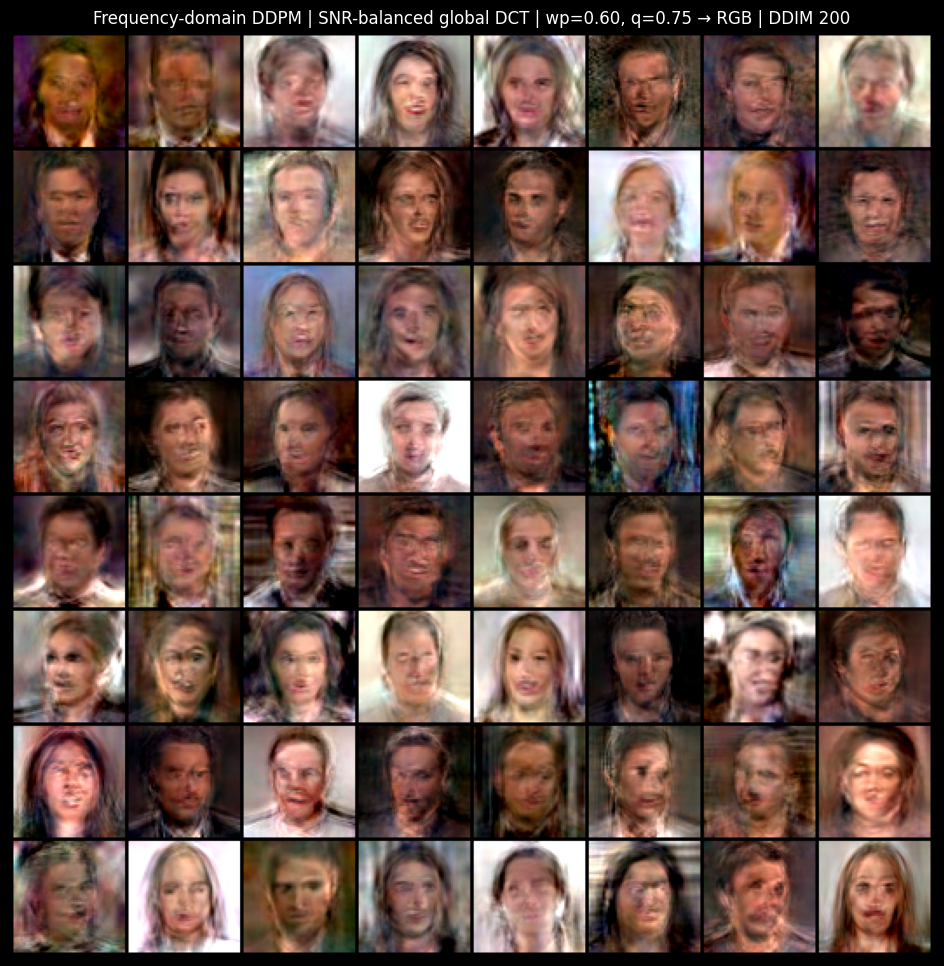

Loaded cached rgb samples -> Frequency_Domain_Diffusion_Artifacts\sample_cache\rgb_v4_overlap_k8s4_wp0.65_sp0.16_rad0.06_spatial_best_rgb_ddim200_n1024_seed12345.pt


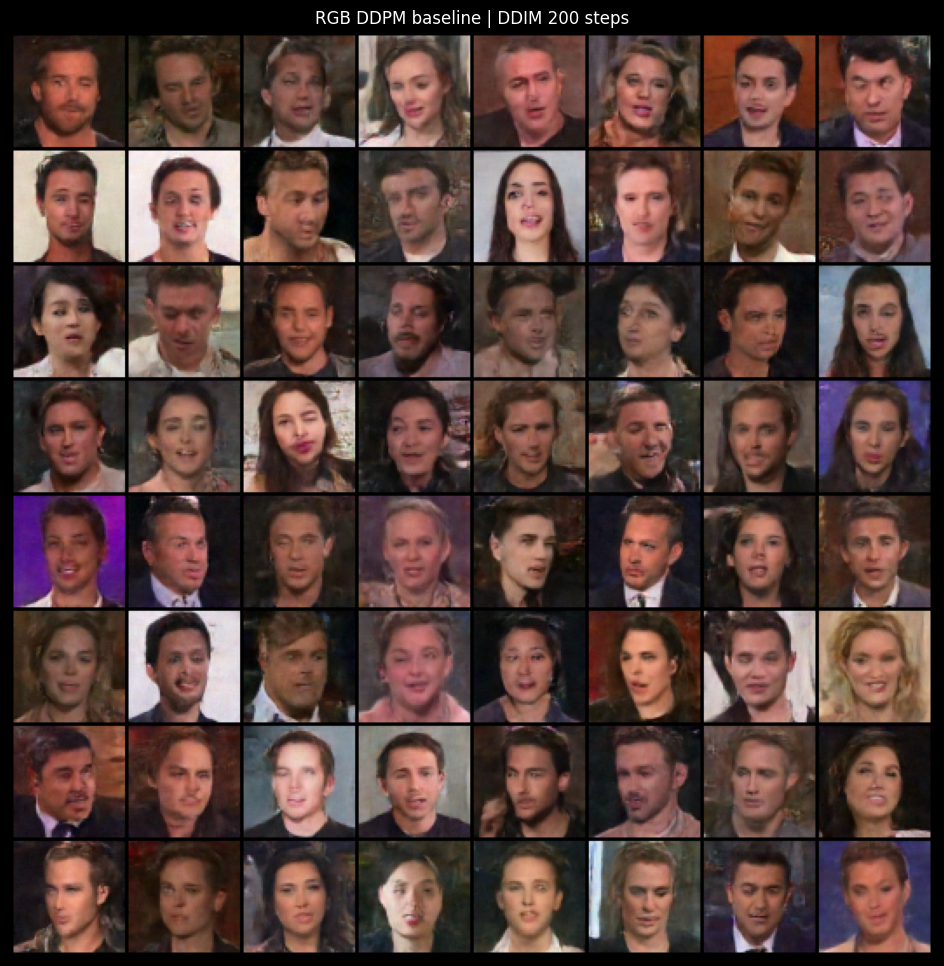

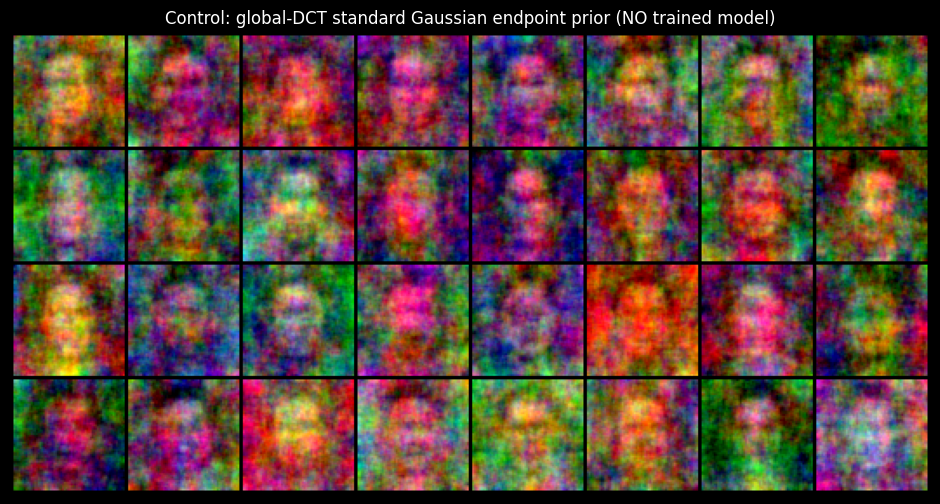

DDIM generation time — frequency: 9350.87s for 1024 images
DDIM generation time — RGB:       5195.47s for 1024 images


,model,n,face_detect_rate,grid_score_p4,FID,IS_mean,IS_std,KID_mean,KID_std
0,Frequency-domain DDPM,1000,0.996094,1.013443,162.152023,1.927299,0.164174,0.129431,0.005890
1,RGB DDPM baseline,1000,1.000000,1.012332,116.306671,2.130013,0.156477,0.076121,0.005369
2,Independent Gaussian DCT prior,1000,0.039062,0.999939,467.720734,1.469239,0.036431,0.605910,0.013553
3,Real held-out reference,1000,1.000000,1.016128,0.000000,NaN,NaN,0.000000,0.000000


Saved metrics -> Frequency_Domain_Diffusion_Artifacts\metrics\v7_trajspec_globaldct_q0.75_wp0.60_abs0.0100_traj0.0040_visual_metrics.csv


,model,mean_spectrum_L1,radial_profile_L1,high_freq_energy_real,high_freq_energy_fake,localized_peak_score,AUC_image_mean,AUC_image_std,AUC_image_folds,AUC_grouped_mean,...,band_SWD,spectral_slope_mean_real,spectral_slope_mean_fake,spectral_slope_std_real,spectral_slope_std_fake,AUC_residualFFT_grouped_mean,AUC_residualFFT_grouped_std,grid_score_p4,n,hf_ratio_to_real
0,Frequency-domain DDPM,0.017638,0.026161,0.002479,0.001273,0.086659,0.932438,0.013815,15,0.739542,...,0.524045,-1.286043,-1.300382,0.148043,0.113479,0.674609,0.084530,1.013443,1000,0.513450
1,RGB DDPM baseline,0.019755,0.028195,0.002479,0.001131,0.102913,0.996447,0.001980,15,0.969322,...,0.735936,-1.286043,-1.208286,0.148043,0.057439,0.957339,0.033962,1.012332,1000,0.456225
2,Independent Gaussian DCT prior,0.010498,0.014424,0.002479,0.003460,0.081030,0.992558,0.005034,15,0.905027,...,0.608968,-1.286043,-1.079665,0.148043,0.017003,0.897518,0.092173,0.999939,1000,1.395836
3,Celeb-DF synthesis,0.009868,0.021548,0.002478,0.003415,0.132014,0.963914,0.008944,15,0.862915,...,0.446676,-1.286475,-1.158079,0.148203,0.123889,0.859755,0.058441,1.021207,992,1.378221


Saved metrics -> Frequency_Domain_Diffusion_Artifacts\metrics\v7_trajspec_globaldct_q0.75_wp0.60_abs0.0100_traj0.0040_spectral_metrics.csv


,model,band_logmean_L1,band_logstd_L1,band_SWD,spectral_slope_mean_real,spectral_slope_mean_fake,spectral_slope_std_real,spectral_slope_std_fake,AUC_residualFFT_grouped_mean,AUC_residualFFT_grouped_std
0,Frequency-domain DDPM,0.418072,0.191631,0.524045,-1.286043,-1.300382,0.148043,0.113479,0.674609,0.084530
1,RGB DDPM baseline,0.523443,0.300185,0.735936,-1.286043,-1.208286,0.148043,0.057439,0.957339,0.033962
2,Independent Gaussian DCT prior,0.494839,0.488206,0.608968,-1.286043,-1.079665,0.148043,0.017003,0.897518,0.092173
3,Celeb-DF synthesis,0.249278,0.089104,0.446676,-1.286475,-1.158079,0.148203,0.123889,0.859755,0.058441


Saved metrics -> Frequency_Domain_Diffusion_Artifacts\metrics\v7_trajspec_globaldct_q0.75_wp0.60_abs0.0100_traj0.0040_spectral_distribution_metrics.csv


,model,band_0,band_1,band_2,band_3,band_4,band_5,band_6,band_7,ratio_to_real_0,ratio_to_real_1,ratio_to_real_2,ratio_to_real_3,ratio_to_real_4,ratio_to_real_5,ratio_to_real_6,ratio_to_real_7
0,Real held-out reference,0.951213,0.037592,0.007634,0.002276,0.000787,0.000337,0.000110,0.000050,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Frequency-domain DDPM,0.955521,0.035539,0.006331,0.001704,0.000557,0.000234,0.000075,0.000039,1.004529,0.945405,0.829225,0.748740,0.707779,0.692830,0.682463,0.779291
2,RGB DDPM baseline,0.962850,0.030071,0.004966,0.001308,0.000441,0.000212,0.000089,0.000062,1.012234,0.799941,0.650492,0.574731,0.560466,0.628905,0.808691,1.249997
3,Independent Gaussian DCT prior,0.936235,0.047487,0.010519,0.003406,0.001311,0.000653,0.000250,0.000139,0.984253,1.263246,1.377826,1.496174,1.665771,1.936039,2.268764,2.782527
4,Celeb-DF synthesis,0.937462,0.047109,0.009991,0.003294,0.001239,0.000576,0.000218,0.000110,0.985544,1.253194,1.308660,1.446955,1.573586,1.709006,1.977462,2.215541


Saved metrics -> Frequency_Domain_Diffusion_Artifacts\metrics\v7_trajspec_globaldct_q0.75_wp0.60_abs0.0100_traj0.0040_radial_band_energy.csv


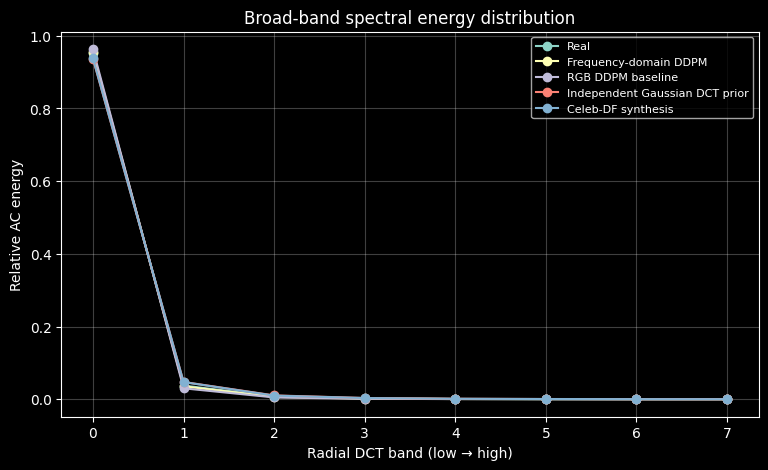

,model,n,AUC_grouped_jpeg_resize_mean,AUC_grouped_jpeg_resize_std,folds,AUC_residualFFT_jpeg_resize_mean,AUC_residualFFT_jpeg_resize_std
0,Frequency-domain DDPM,512,0.681088,0.067311,15,0.715701,0.079687
1,RGB DDPM baseline,512,0.769334,0.074593,15,0.772685,0.072437
2,Independent Gaussian DCT prior,512,0.998708,0.002912,15,0.979157,0.026733
3,Celeb-DF synthesis,512,0.849429,0.089433,15,0.857190,0.092075


Saved metrics -> Frequency_Domain_Diffusion_Artifacts\metrics\v7_trajspec_globaldct_q0.75_wp0.60_abs0.0100_traj0.0040_forensic_robustness_jpeg_resize.csv


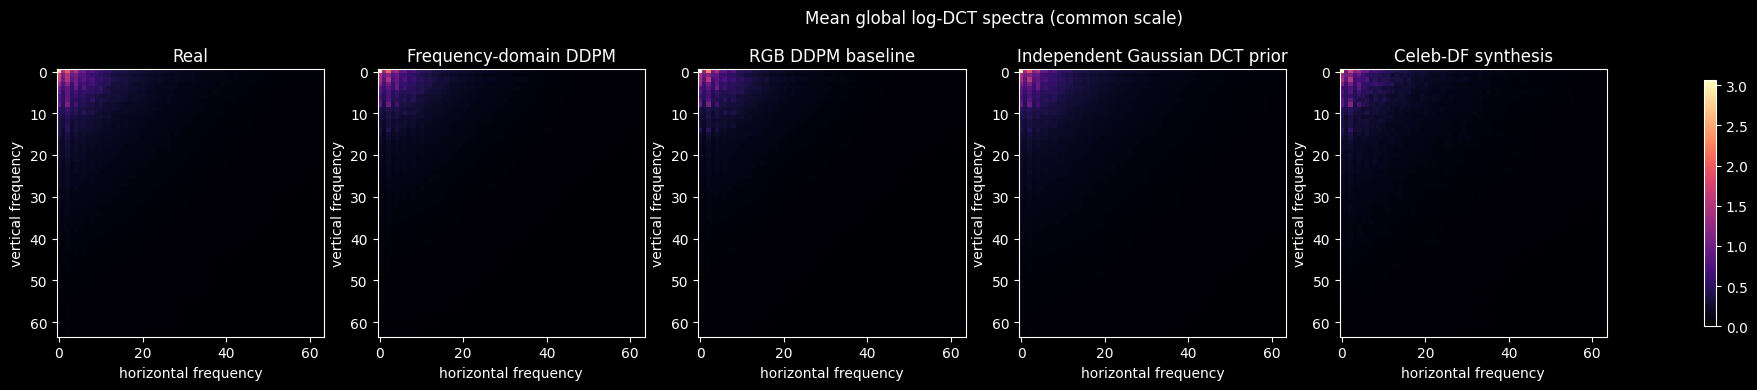

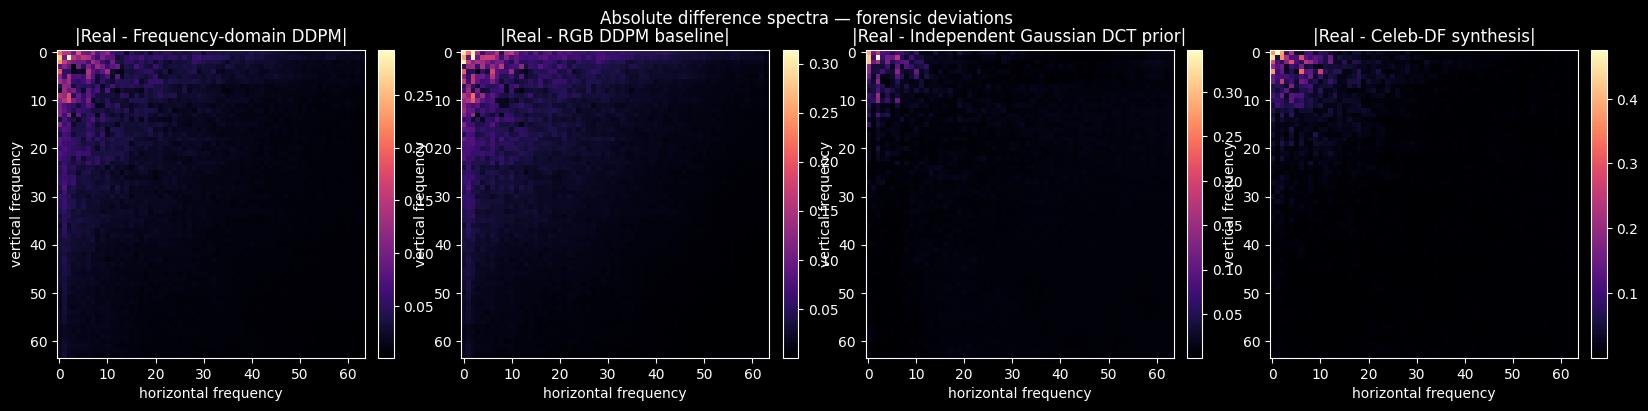

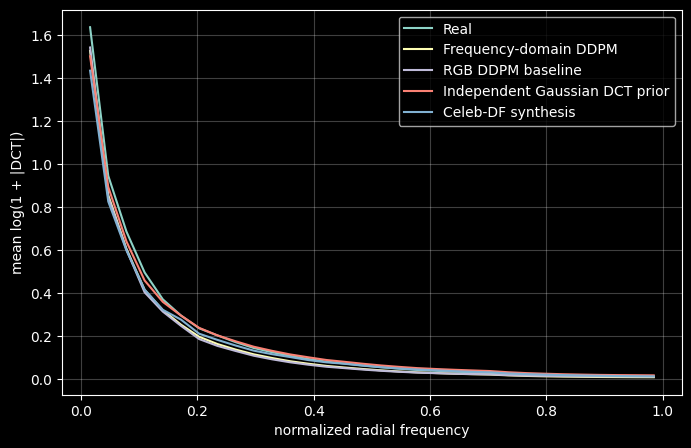

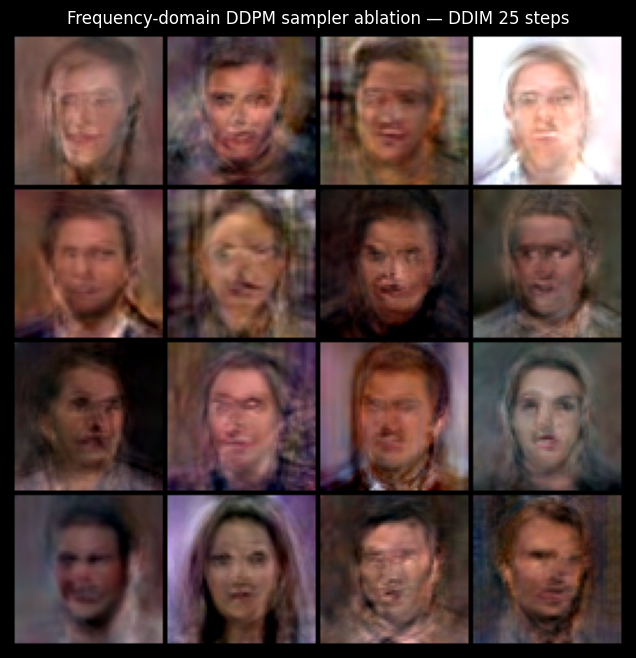

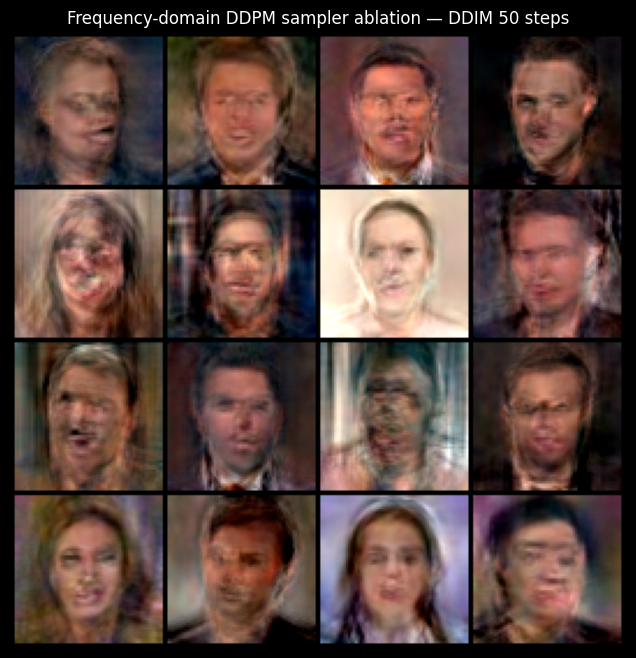

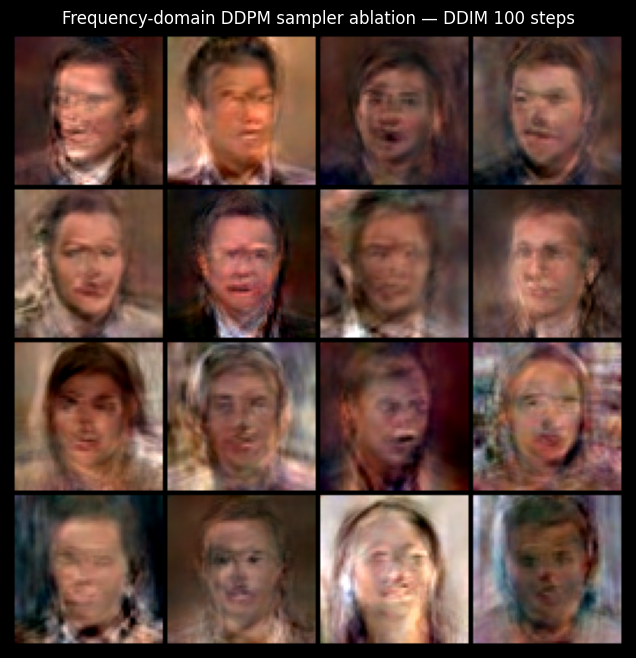

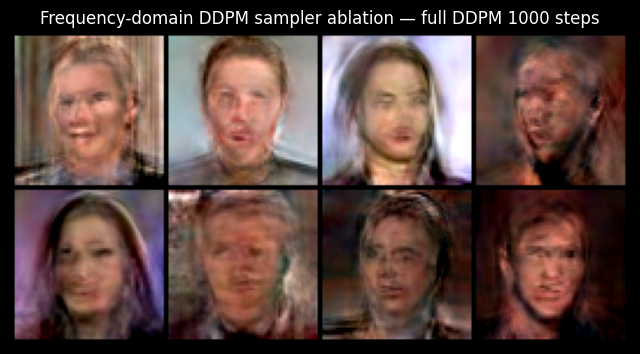

,sampler,steps,n,seconds,images_per_second,face_detect_rate,grid_score_p4,mean_spectrum_L1,radial_profile_L1,high_freq_energy_fake,localized_peak_score
0,DDIM,25,64,9.829629,6.510928,1.000000,1.025187,0.029120,0.046224,0.000793,0.134074
1,DDIM,50,64,10.532166,6.076623,0.984375,1.014169,0.022726,0.036242,0.001038,0.123005
2,DDIM,100,64,20.190286,3.169841,0.984375,1.015606,0.022736,0.035210,0.000986,0.120969
3,DDIM,200,64,40.285420,1.588664,0.953125,1.015763,0.017100,0.027125,0.001283,0.107444
4,DDPM,1000,8,27.841269,0.287343,1.000000,0.992305,0.027543,0.038313,0.001631,0.227757


Measured DDIM-200 throughput speedup vs DDPM-1000: 5.53x
Saved metrics -> Frequency_Domain_Diffusion_Artifacts\metrics\v7_trajspec_globaldct_q0.75_wp0.60_abs0.0100_traj0.0040_sampler_ablation.csv


In [8]:
# evaluation helpers
@torch.no_grad()
def collect_real(loader: DataLoader, n: int) -> torch.Tensor:
    xs, count = [], 0
    for x in loader:
        xs.append(x.cpu()); count += len(x)
        if count >= n: break
    return torch.cat(xs, dim=0)[:n]


# balanced source sampling
def balanced_group_sample_indices(groups: Sequence[str], n: int, seed: int = 42) -> np.ndarray:

    groups = np.asarray(groups, dtype=object)
    n = min(int(n), len(groups))
    if n <= 0:
        return np.asarray([], dtype=int)
    rng = np.random.default_rng(seed)
    unique = rng.permutation(np.unique(groups))
    queues = {}
    for g in unique:
        idx = np.flatnonzero(groups == g)
        queues[g] = list(rng.permutation(idx))
    out = []
    while len(out) < n:
        progressed = False
        for g in unique:
            if queues[g]:
                out.append(int(queues[g].pop()))
                progressed = True
                if len(out) >= n:
                    break
        if not progressed:
            break
    return np.asarray(out, dtype=int)


# sample generation
@torch.no_grad()
def generate_samples(artifact: dict, domain: str, n: int, cfg: Config, codec: nn.Module,
                     sampler: str = "ddim", ddim_steps: Optional[int] = None) -> Tuple[torch.Tensor, float]:
    model = artifact["ema"].to(cfg.device).eval()
    diffusion = artifact["diffusion"].to(cfg.device)
    outs = []
    start = time.perf_counter()
    for i in range(0, n, cfg.eval_batch_size):
        b = min(cfg.eval_batch_size, n - i)
        if domain == "frequency":
            shape = (b, codec.latent_channels, codec.latent_size, codec.latent_size)
            clip = cfg.spectral_sample_clip
        else:
            shape = (b, 3, cfg.image_size, cfg.image_size)
            clip = 1.0
        if sampler == "ddim":
            z = diffusion.ddim_sample(model, shape, cfg.device,
                                      steps=cfg.ddim_steps if ddim_steps is None else ddim_steps,
                                      eta=cfg.ddim_eta, clip_range=clip)
        elif sampler == "ddpm":
            z = diffusion.ddpm_sample(model, shape, cfg.device, clip_range=clip)
        else:
            raise ValueError(sampler)
        rgb = z if domain == "rgb" else codec.decode(z, clamp=True)
        outs.append(rgb.clamp(-1, 1).cpu())
    return torch.cat(outs, dim=0), time.perf_counter() - start


# sample cache
@torch.no_grad()
def _sample_cache_path(artifact: dict, domain: str, n: int, cfg: Config,
                       sampler: str, ddim_steps: Optional[int]) -> Path:
    ckpt_stem = Path(artifact.get("checkpoint", domain)).stem
    steps = cfg.timesteps if sampler == "ddpm" else int(
        cfg.ddim_steps if ddim_steps is None else ddim_steps
    )
    return Path(cfg.sample_cache_dir) / (
        f"{ckpt_stem}_{domain}_{sampler}{steps}_n{n}_seed{cfg.eval_seed}.pt"
    )


@torch.no_grad()
def generate_or_load_samples(artifact: dict, domain: str, n: int, cfg: Config,
                             codec: nn.Module, sampler: str = "ddim",
                             ddim_steps: Optional[int] = None):
    cache_path = _sample_cache_path(artifact, domain, n, cfg, sampler, ddim_steps)

    if cfg.reuse_generated_samples and cache_path.exists():
        try:
            payload = torch.load(cache_path, map_location="cpu", weights_only=False)
            images = payload["images"].float()
            elapsed = float(payload.get("generation_seconds", float("nan")))
            print(f"Loaded cached {domain} samples -> {_display_path(cache_path)}")
            return images, elapsed, True
        except Exception as exc:
            print("Unreadable sample cache; regenerating:", repr(exc))

    devices = []
    if cfg.device.startswith("cuda") and torch.cuda.is_available():
        devices = [torch.cuda.current_device()]

    with torch.random.fork_rng(devices=devices, enabled=True):
        torch.manual_seed(cfg.eval_seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(cfg.eval_seed)
        images, elapsed = generate_samples(
            artifact, domain, n, cfg, codec,
            sampler=sampler, ddim_steps=ddim_steps
        )

    if cfg.cache_generated_samples:
        _atomic_torch_save({
            "images": images.to(torch.float16).cpu(),
            "domain": domain,
            "sampler": sampler,
            "ddim_steps": None if ddim_steps is None else int(ddim_steps),
            "n": int(n),
            "eval_seed": int(cfg.eval_seed),
            "generation_seconds": float(elapsed),
            "checkpoint": artifact.get("checkpoint"),
            "experiment_name": cfg.experiment_name,
        }, str(cache_path))
        print("Saved sample cache ->", _display_path(cache_path))

    return images, elapsed, False


# metric output
def save_metrics_table(df: pd.DataFrame, name: str, cfg: Config):
    path = Path(cfg.metrics_dir) / f"{cfg.experiment_name}_{name}.csv"
    df.to_csv(path, index=False)
    print("Saved metrics ->", _display_path(path))
    return path


# gaussian control
def independent_gaussian_dct_control(n: int, cfg: Config, codec: nn.Module) -> torch.Tensor:
    outs = []
    for i in range(0, n, cfg.eval_batch_size):
        b = min(cfg.eval_batch_size, n - i)
        shape = (b, codec.latent_channels, codec.latent_size, codec.latent_size)
        if hasattr(codec, "independent_gaussian_prior"):
            z = codec.independent_gaussian_prior(shape, cfg.device)
        else:
            z = torch.randn(shape, device=cfg.device)
        outs.append(codec.decode(z, clamp=True).cpu())
    return torch.cat(outs, dim=0)


# visual metrics
def compute_fid_is_kid(real: torch.Tensor, fake: torch.Tensor, device: str) -> Dict[str, float]:
    base = {"FID": float("nan"), "IS_mean": float("nan"), "IS_std": float("nan"),
            "KID_mean": float("nan"), "KID_std": float("nan")}
    if not TORCHMETRICS_AVAILABLE:
        return base
    try:
        fid = FrechetInceptionDistance(feature=2048, normalize=True).to(device)
        inc = InceptionScore(normalize=True).to(device)
        subset = max(10, min(100, len(real), len(fake)))
        kid = KernelInceptionDistance(subset_size=subset, normalize=True).to(device)
        bs = 64
        for i in range(0, len(real), bs):
            r = to_01(real[i:i+bs]).to(device)
            fid.update(r, real=True); kid.update(r, real=True)
        for i in range(0, len(fake), bs):
            f = to_01(fake[i:i+bs]).to(device)
            fid.update(f, real=False); kid.update(f, real=False); inc.update(f)
        fid_value = float(fid.compute().item())
        is_mean, is_std = inc.compute()
        kid_mean, kid_std = kid.compute()
        return {
            "FID": fid_value,
            "IS_mean": float(is_mean.item()), "IS_std": float(is_std.item()),
            "KID_mean": float(kid_mean.item()), "KID_std": float(kid_std.item())
        }
    except Exception as exc:
        print("FID/IS/KID failed:", repr(exc))
        print("Ensure torchmetrics[image] + torch-fidelity are installed and Inception weights are available.")
        return base


def _to_uint8_rgb(x: torch.Tensor) -> np.ndarray:
    return (to_01(x).permute(1,2,0).numpy() * 255.0).round().astype(np.uint8)


# face metric
def _image_has_face(arr_rgb: np.ndarray) -> bool:

    if FACENET_AVAILABLE:
        detector = _get_mtcnn(CFG)
        if detector is not None:
            try:
                boxes, probs = detector.detect(Image.fromarray(arr_rgb))
                if boxes is not None and probs is not None:
                    return any(p is not None and float(p) >= 0.80 for p in probs)
            except Exception:
                pass
    cascade = _get_face_cascade()
    if CV2_AVAILABLE and cascade is not None:
        gray = cv2.cvtColor(arr_rgb, cv2.COLOR_RGB2GRAY)
        faces = cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=4, minSize=(12, 12))
        return len(faces) > 0
    return False


def face_detection_rate(images: torch.Tensor, max_images: int = 256) -> float:
    if len(images) == 0:
        return float("nan")
    if not FACENET_AVAILABLE and (not CV2_AVAILABLE or _get_face_cascade() is None):
        return float("nan")
    imgs = images[:min(len(images), max_images)]
    hits = 0
    for x in imgs:
        hits += int(_image_has_face(_to_uint8_rgb(x.cpu())))
    return hits / len(imgs)


# robustness transform
@torch.no_grad()
def jpeg_resize_launder(images: torch.Tensor, out_size: int, resize_size: int,
                        jpeg_min: int, jpeg_max: int, seed: int = 42) -> torch.Tensor:

    rng = np.random.default_rng(seed)
    outs = []
    for x in images.cpu():
        arr = _to_uint8_rgb(x)
        im = Image.fromarray(arr).resize((resize_size, resize_size), Image.Resampling.BICUBIC)
        q = int(rng.integers(jpeg_min, jpeg_max + 1))
        buf = io.BytesIO()
        im.save(buf, format="JPEG", quality=q, subsampling=0)
        buf.seek(0)
        rec = Image.open(buf).convert("RGB").resize((out_size, out_size), Image.Resampling.BICUBIC)
        a = np.asarray(rec).copy()
        t = torch.from_numpy(a).permute(2,0,1).float() / 127.5 - 1.0
        outs.append(t)
    return torch.stack(outs) if outs else torch.empty((0,3,out_size,out_size))


# residual-frequency probe
def residual_fft_grouped_probe(real: torch.Tensor, fake: torch.Tensor,
                               real_groups: Sequence[str], fake_groups: Sequence[str],
                               cfg: Config, seed: int) -> Dict[str, float]:
    Xr = residual_fft_probe_features(real, cfg.residual_fft_kernel, cfg.residual_fft_pool)
    Xf = residual_fft_probe_features(fake, cfg.residual_fft_kernel, cfg.residual_fft_pool)
    return grouped_auc_from_features(Xr, Xf, real_groups, fake_groups,
                                     cfg.probe_cv_splits, cfg.probe_cv_repeats, seed)

# run evaluation
if not artifacts or "frequency" not in artifacts:
    print("No frequency model is available. Run the Train section first.")
else:
    required_real = max(CFG.eval_generate_samples, CFG.metric_samples, CFG.forensic_probe_samples, len(eval_loader.dataset))
    real_eval = collect_real(eval_loader, required_real)
    print(f"Forensic real groups represented: {len(np.unique(eval_group_ids[:len(real_eval)]))}")
    if len(real_eval) < CFG.metric_samples:
        print(f"WARNING: only {len(real_eval)} held-out real frames available; FID requested {CFG.metric_samples}.")
    celebdf_fake_ref = None
    if fake_eval_loader is not None:
        celebdf_fake_ref = collect_real(fake_eval_loader, CFG.forensic_probe_samples)

    n_gen = CFG.eval_generate_samples
    # frequency samples
    freq_fake, t_freq, freq_from_cache = generate_or_load_samples(
        artifacts["frequency"], "frequency", n_gen, CFG, frequency_codec,
        sampler="ddim", ddim_steps=CFG.ddim_steps
    )
    show_images(freq_fake[:64], nrow=8,
                title=(f"Frequency-domain DDPM | SNR-balanced global DCT | wp={CFG.spectral_whitening_power:.2f}, "
                       f"q={CFG.diffusion_balance_power:.2f} → RGB | DDIM {CFG.ddim_steps}"))

    # rgb baseline samples
    rgb_fake, t_rgb = None, float("nan")
    rgb_from_cache = False
    if "rgb" in artifacts and CFG.generate_rgb_samples:
        rgb_fake, t_rgb, rgb_from_cache = generate_or_load_samples(
            artifacts["rgb"], "rgb", n_gen, CFG, frequency_codec,
            sampler="ddim", ddim_steps=CFG.ddim_steps
        )
        show_images(
            rgb_fake[:64], nrow=8,
            title=f"RGB DDPM baseline | DDIM {CFG.ddim_steps} steps"
        )
    elif "rgb" in artifacts:
        print(
            "RGB checkpoint loaded; generation is disabled. "
            "RGB metrics require generated baseline samples."
        )

    # independent spectral control
    gaussian_control = None
    if CFG.run_gaussian_spectral_control:
        gaussian_control = independent_gaussian_dct_control(min(n_gen, CFG.forensic_probe_samples), CFG, frequency_codec)
        show_images(gaussian_control[:32], nrow=8,
                    title="Control: global-DCT standard Gaussian endpoint prior (NO trained model)", figsize=(12,6))

    print(f"DDIM generation time — frequency: {t_freq:.2f}s for {n_gen} images")
    if rgb_fake is not None:
        print(f"DDIM generation time — RGB:       {t_rgb:.2f}s for {n_gen} images")


    # visual quality metrics
    metric_rows = []
    metric_n = min(CFG.metric_samples, len(real_eval), len(freq_fake))
    if CFG.balanced_metric_sampling:
        metric_real_idx = balanced_group_sample_indices(eval_group_ids[:len(real_eval)], metric_n, CFG.seed + 2026)
        real_metric = real_eval[metric_real_idx]
    else:
        real_metric = real_eval[:metric_n]
    if metric_n < 1000:
        print(f"FID caution: metric_n={metric_n}; treat absolute FID as diagnostic and use KID/relative comparisons too.")
    metric_rows.append({
        "model": "Frequency-domain DDPM", "n": metric_n,
        "face_detect_rate": face_detection_rate(freq_fake[:metric_n], CFG.face_metric_samples),
        "grid_score_p4": block_seam_score(freq_fake[:metric_n], codec_seam_period(frequency_codec, CFG)),
        **compute_fid_is_kid(real_metric, freq_fake[:metric_n], CFG.device)
    })
    if rgb_fake is not None:
        n = min(metric_n, len(rgb_fake))
        metric_rows.append({
            "model": "RGB DDPM baseline", "n": n,
            "face_detect_rate": face_detection_rate(rgb_fake[:n], CFG.face_metric_samples),
            "grid_score_p4": block_seam_score(rgb_fake[:n], codec_seam_period(frequency_codec, CFG)),
            **compute_fid_is_kid(real_metric[:n], rgb_fake[:n], CFG.device)
        })
    if gaussian_control is not None:
        n = min(metric_n, len(gaussian_control))
        metric_rows.append({
            "model": "Independent Gaussian DCT prior", "n": n,
            "face_detect_rate": face_detection_rate(gaussian_control[:n], CFG.face_metric_samples),
            "grid_score_p4": block_seam_score(gaussian_control[:n], codec_seam_period(frequency_codec, CFG)),
            **compute_fid_is_kid(real_metric[:n], gaussian_control[:n], CFG.device)
        })

    metric_rows.append({
        "model": "Real held-out reference", "n": metric_n,
        "face_detect_rate": face_detection_rate(real_metric, CFG.face_metric_samples),
        "grid_score_p4": block_seam_score(real_metric, codec_seam_period(frequency_codec, CFG)),
        "FID": 0.0, "IS_mean": float("nan"), "IS_std": float("nan"),
        "KID_mean": 0.0, "KID_std": 0.0
    })
    metric_df = pd.DataFrame(metric_rows)
    display(metric_df)
    save_metrics_table(metric_df, "visual_metrics", CFG)


    # spectral and forensic metrics
    comparison_sets = {"Frequency-domain DDPM": freq_fake}
    if rgb_fake is not None:
        comparison_sets["RGB DDPM baseline"] = rgb_fake
    if gaussian_control is not None:
        comparison_sets["Independent Gaussian DCT prior"] = gaussian_control
    if celebdf_fake_ref is not None and len(celebdf_fake_ref):
        comparison_sets["Celeb-DF synthesis"] = celebdf_fake_ref

    spec_rows = []
    for name, imgs in comparison_sets.items():
        n = min(CFG.forensic_probe_samples, len(real_eval), len(imgs))
        r_idx = balanced_group_sample_indices(eval_group_ids[:len(real_eval)], n, CFG.seed)
        real_probe = real_eval[r_idx]
        real_groups_probe = eval_group_ids[r_idx]
        row = spectral_summary(real_probe, imgs[:n], analysis_dct, name)
        legacy_auc = forensic_linear_probe_cv(
            real_probe, imgs[:n], analysis_dct,
            CFG.probe_cv_splits, CFG.probe_cv_repeats, CFG.seed
        )
        row.update({
            "AUC_image_mean": legacy_auc.get("AUC_mean", float("nan")),
            "AUC_image_std": legacy_auc.get("AUC_std", float("nan")),
            "AUC_image_folds": legacy_auc.get("AUC_folds", 0),
        })

        real_groups = real_groups_probe
        if name == "Celeb-DF synthesis" and fake_eval_group_ids is not None:
            fake_groups = fake_eval_group_ids[:n]
        else:

            fake_groups = np.asarray([f"generated_{i:06d}" for i in range(n)], dtype=object)
        row.update(forensic_linear_probe_grouped_cv(
            real_probe, imgs[:n], analysis_dct,
            real_groups=real_groups, fake_groups=fake_groups,
            splits=CFG.probe_cv_splits, repeats=CFG.probe_cv_repeats, seed=CFG.seed
        ))
        row.update(spectral_distribution_summary(
            real_probe, imgs[:n], analysis_dct, bins=CFG.spectral_distribution_bins,
            projections=CFG.spectral_swd_projections, seed=CFG.seed
        ))
        if CFG.run_residual_fft_probe:
            _rf = residual_fft_grouped_probe(real_probe, imgs[:n], real_groups, fake_groups, CFG, CFG.seed + 211)
            row["AUC_residualFFT_grouped_mean"] = _rf.get("AUC_grouped_mean", float("nan"))
            row["AUC_residualFFT_grouped_std"] = _rf.get("AUC_grouped_std", float("nan"))
        row["grid_score_p4"] = block_seam_score(imgs[:n], codec_seam_period(frequency_codec, CFG))
        row["n"] = n
        spec_rows.append(row)
    spec_df = pd.DataFrame(spec_rows)
    spec_df["hf_ratio_to_real"] = spec_df["high_freq_energy_fake"] / spec_df["high_freq_energy_real"].clip(lower=1e-12)
    display(spec_df)
    save_metrics_table(spec_df, "spectral_metrics", CFG)
    dist_cols = [c for c in ["model","band_logmean_L1","band_logstd_L1","band_SWD",
                              "spectral_slope_mean_real","spectral_slope_mean_fake",
                              "spectral_slope_std_real","spectral_slope_std_fake",
                              "AUC_residualFFT_grouped_mean","AUC_residualFFT_grouped_std"] if c in spec_df.columns]
    dist_df = spec_df[dist_cols].copy()
    display(dist_df); save_metrics_table(dist_df, "spectral_distribution_metrics", CFG)


    # radial band comparison
    band_n = min(CFG.forensic_probe_samples, len(real_eval))
    band_r_idx = balanced_group_sample_indices(eval_group_ids[:len(real_eval)], band_n, CFG.seed + 33)
    real_band_ref = real_eval[band_r_idx]
    real_bands = radial_band_energy_fractions(real_band_ref, analysis_dct, bins=CFG.band_aux_bins)
    band_rows = [{"model": "Real held-out reference", **{f"band_{i}": float(v) for i,v in enumerate(real_bands)}}]
    for _name, _imgs in comparison_sets.items():
        _n = min(band_n, len(_imgs))
        _b = radial_band_energy_fractions(_imgs[:_n], analysis_dct, bins=CFG.band_aux_bins)
        _row = {"model": _name}
        for _i, _v in enumerate(_b):
            _row[f"band_{_i}"] = float(_v)
            _row[f"ratio_to_real_{_i}"] = float(_v / max(real_bands[_i], 1e-12))
        band_rows.append(_row)
    band_df = pd.DataFrame(band_rows)
    display(band_df)
    save_metrics_table(band_df, "radial_band_energy", CFG)

    plt.figure(figsize=(9,5))
    x_band = np.arange(CFG.band_aux_bins)
    plt.plot(x_band, real_bands, marker="o", label="Real")
    for _name, _imgs in comparison_sets.items():
        _n = min(band_n, len(_imgs))
        _b = radial_band_energy_fractions(_imgs[:_n], analysis_dct, bins=CFG.band_aux_bins)
        plt.plot(x_band, _b, marker="o", label=_name)
    plt.xlabel("Radial DCT band (low → high)"); plt.ylabel("Relative AC energy")
    plt.title("Broad-band spectral energy distribution")
    plt.grid(alpha=0.25); plt.legend(fontsize=8); plt.show()


    # jpeg and resize robustness
    robust_df = pd.DataFrame()
    if CFG.run_forensic_robustness:
        robust_rows = []
        robust_n = min(CFG.forensic_robust_samples, len(real_eval))
        rr_idx = balanced_group_sample_indices(eval_group_ids[:len(real_eval)], robust_n, CFG.seed + 91)
        rr = real_eval[rr_idx]
        rr_groups = eval_group_ids[rr_idx]
        rr_l = jpeg_resize_launder(rr, CFG.image_size, CFG.forensic_robust_resize,
                                   CFG.forensic_robust_jpeg_min, CFG.forensic_robust_jpeg_max, CFG.seed + 501)
        for _name, _imgs in comparison_sets.items():
            _n = min(robust_n, len(_imgs))
            if _n < 20:
                continue
            _fake = _imgs[:_n]
            _fake_l = jpeg_resize_launder(_fake, CFG.image_size, CFG.forensic_robust_resize,
                                          CFG.forensic_robust_jpeg_min, CFG.forensic_robust_jpeg_max, CFG.seed + 501)
            if _name == "Celeb-DF synthesis" and fake_eval_group_ids is not None:
                _fg = fake_eval_group_ids[:_n]
            else:
                _fg = np.asarray([f"generated_{i:06d}" for i in range(_n)], dtype=object)
            _res = forensic_linear_probe_grouped_cv(
                rr_l[:_n], _fake_l, analysis_dct,
                real_groups=rr_groups[:_n], fake_groups=_fg,
                splits=CFG.probe_cv_splits, repeats=CFG.probe_cv_repeats, seed=CFG.seed + 77
            )
            _row = {"model": _name, "n": _n,
                    "AUC_grouped_jpeg_resize_mean": _res.get("AUC_grouped_mean", float("nan")),
                    "AUC_grouped_jpeg_resize_std": _res.get("AUC_grouped_std", float("nan")),
                    "folds": _res.get("AUC_grouped_folds", 0)}
            if CFG.run_residual_fft_probe:
                _rrf = residual_fft_grouped_probe(rr_l[:_n], _fake_l, rr_groups[:_n], _fg, CFG, CFG.seed + 377)
                _row["AUC_residualFFT_jpeg_resize_mean"] = _rrf.get("AUC_grouped_mean", float("nan"))
                _row["AUC_residualFFT_jpeg_resize_std"] = _rrf.get("AUC_grouped_std", float("nan"))
            robust_rows.append(_row)
        robust_df = pd.DataFrame(robust_rows)
        display(robust_df)
        save_metrics_table(robust_df, "forensic_robustness_jpeg_resize", CFG)

    plot_n = min(CFG.forensic_probe_samples, len(real_eval))
    plot_idx = balanced_group_sample_indices(eval_group_ids[:len(real_eval)], plot_n, CFG.seed)
    plot_sets = {k: v[:min(plot_n, len(v))] for k, v in comparison_sets.items()}
    plot_spectral_comparison(real_eval[plot_idx], plot_sets, analysis_dct)


    # sampler ablation
    if CFG.run_sampler_ablation:
        ablation_rows = []
        n_ab = min(CFG.sampler_ablation_samples, len(real_eval))
        for steps in CFG.sampler_ablation_steps:
            samples, sec = generate_samples(artifacts["frequency"], "frequency", n_ab, CFG, frequency_codec,
                                            sampler="ddim", ddim_steps=steps)
            _ab_idx = balanced_group_sample_indices(eval_group_ids[:len(real_eval)], n_ab, CFG.seed + 700 + int(steps))
            row = spectral_summary(real_eval[_ab_idx], samples, analysis_dct, f"DDIM-{steps}")
            row.update({
                "sampler": "DDIM", "steps": steps, "n": n_ab, "seconds": sec,
                "images_per_second": n_ab / max(sec, 1e-8),
                "face_detect_rate": face_detection_rate(samples, min(CFG.face_metric_samples, n_ab)),
                "grid_score_p4": block_seam_score(samples, codec_seam_period(frequency_codec, CFG))
            })
            ablation_rows.append(row)
            if steps in (25, 50, 100):
                show_images(samples[:16], nrow=4, title=f"Frequency-domain DDPM sampler ablation — DDIM {steps} steps", figsize=(8,8))

        if CFG.sampler_ablation_full_ddpm:
            n_ddpm = min(CFG.sampler_ablation_full_ddpm_samples, len(real_eval))
            samples, sec = generate_samples(artifacts["frequency"], "frequency", n_ddpm, CFG, frequency_codec, sampler="ddpm")
            _dd_idx = balanced_group_sample_indices(eval_group_ids[:len(real_eval)], n_ddpm, CFG.seed + 1700)
            row = spectral_summary(real_eval[_dd_idx], samples, analysis_dct, "DDPM-1000")
            row.update({
                "sampler": "DDPM", "steps": CFG.timesteps, "n": n_ddpm, "seconds": sec,
                "images_per_second": n_ddpm / max(sec, 1e-8),
                "face_detect_rate": face_detection_rate(samples, n_ddpm),
                "grid_score_p4": block_seam_score(samples, codec_seam_period(frequency_codec, CFG))
            })
            ablation_rows.append(row)
            show_images(samples[:16], nrow=4, title="Frequency-domain DDPM sampler ablation — full DDPM 1000 steps", figsize=(8,8))

        ablation_df = pd.DataFrame(ablation_rows)
        display(ablation_df[["sampler", "steps", "n", "seconds", "images_per_second", "face_detect_rate",
                             "grid_score_p4", "mean_spectrum_L1", "radial_profile_L1",
                             "high_freq_energy_fake", "localized_peak_score"]])
        if (ablation_df["sampler"] == "DDPM").any() and (ablation_df["sampler"] == "DDIM").any():
            ddpm_ips = float(ablation_df.loc[ablation_df["sampler"] == "DDPM", "images_per_second"].iloc[0])
            ddim50_rows = ablation_df[(ablation_df["sampler"] == "DDIM") & (ablation_df["steps"] == CFG.ddim_steps)]
            if len(ddim50_rows):
                ddim_ips = float(ddim50_rows["images_per_second"].iloc[0])
                print(f"Measured DDIM-{CFG.ddim_steps} throughput speedup vs DDPM-{CFG.timesteps}: {ddim_ips / max(ddpm_ips, 1e-12):.2f}x")
        save_metrics_table(ablation_df, "sampler_ablation", CFG)


## Results

The final comparison shows a clear trade-off. The RGB baseline produces better-looking images according to FID, KID and Inception Score, while the frequency-domain model is consistently closer to the real data on the main spectral and forensic measures.

| Metric | Frequency-domain DDPM | RGB DDPM baseline |
|---|---:|---:|
| Face detection rate | 0.9961 | 1.0000 |
| FID ↓ | 162.15 | 116.31 |
| KID ↓ | 0.12943 | 0.07612 |
| Inception Score ↑ | 1.93 ± 0.16 | 2.13 ± 0.16 |
| Mean-spectrum L1 ↓ | 0.01764 | 0.01976 |
| Radial-profile L1 ↓ | 0.02616 | 0.02820 |
| High-frequency energy / real | 0.513 | 0.456 |
| Band SWD ↓ | 0.524 | 0.736 |
| Grouped DCT AUC ↓ | 0.740 | 0.969 |
| Residual-FFT grouped AUC ↓ | 0.675 | 0.957 |
| JPEG+resize DCT AUC ↓ | 0.681 | 0.769 |
| JPEG+resize residual-FFT AUC ↓ | 0.716 | 0.773 |
| Localized peak score ↓ | 0.0867 | 0.1029 |
| Grid score (period 4) | 1.0134 | 1.0123 |

For the grouped forensic probes, an AUC closer to 0.5 means that real and generated images are harder to separate. The frequency-domain model therefore reduces detectability substantially compared with the RGB baseline, although the generated samples are still distinguishable from real images.

The period-4 grid score does not show a meaningful improvement for the frequency model. This is important because it means that the result should be described as a reduction of the overall spectral fingerprint, not as a complete removal of every grid-like artifact.

### DDIM sampling ablation

| Sampler | Steps | Images/s | Mean-spectrum L1 ↓ | Radial-profile L1 ↓ |
|---|---:|---:|---:|---:|
| DDIM | 25 | 6.22 | 0.0291 | 0.0462 |
| DDIM | 50 | 5.94 | 0.0227 | 0.0362 |
| DDIM | 100 | 3.13 | 0.0227 | 0.0352 |
| DDIM | 200 | 1.57 | 0.0171 | 0.0271 |
| DDPM | 1000 | 0.29 | 0.0275 | 0.0383 |

On this machine, DDIM-200 reached about **5.49x** the measured throughput of the 1000-step DDPM sampler. The DDPM timing used a smaller batch because of the much higher sampling cost, so this number should be interpreted as a hardware-specific throughput measurement.

## Discussion and conclusion

The experiments support the main idea of the project only partially, but in a useful way. Moving the diffusion state to the DCT domain improves the match to the real spectral distribution and makes the generated images less separable from real faces with simple frequency-based forensic probes. At the same time, the RGB baseline is clearly better in visual quality. In this setup, improving the spectral statistics therefore does not automatically improve perceptual quality.

A useful sanity check is the independent Gaussian DCT control. It obtains a low mean-spectrum error, but its FID is about 468 and the face detection rate is only about 4%. This shows that reproducing marginal or average spectral statistics is not enough to generate coherent faces. The diffusion model must also learn the dependencies between coefficients.

The main conclusion is that the frequency-domain DDPM **mitigates** the synthetic spectral fingerprint compared with the RGB DDPM, but it does not remove it. The grouped DCT AUC decreases from 0.969 to 0.740 and the residual-FFT AUC from 0.957 to 0.675. These differences also remain after JPEG compression and resizing. However, the period-4 grid score is almost unchanged, so the improvement is not uniform across all artifact measures.

The main limitations are the 64 x 64 resolution, the use of a single face dataset for generation, and the lower visual fidelity of the frequency model. A natural next step would be to test a larger model and resolution, or to use a hybrid objective that keeps the spectral advantages while improving spatial detail.

## References

The project is mainly based on the frequency-forensics motivation of Frank et al. and Corvi et al., together with the diffusion formulation discussed in the course and the recent work on frequency-domain diffusion.

1. Frank, J. et al., *Leveraging Frequency Analysis for Deep Fake Image Recognition*, ICML, 2020.
2. Corvi, R. et al., *On the Detection of Synthetic Images Generated by Diffusion Models*, ICASSP, 2023.
3. Xu, L. et al., *Text-to-image with Frequency Domain Diffusion Models*, SPIE, 2025.
4. Song, T. et al., *FilterDiff: Noise-free Frequency-domain Diffusion Models for Accelerated MRI Reconstruction*, MICCAI, 2025.